# Failure mode analysis

Explores why queries are wrong both before and after adding gget virus as a tool.
- Categorizes failure modes (over-count, under-count, no result, error)
- Analyzes whether tools return more or less than expected
- Compares failure modes per virus
- Examines reasoning from JSON reports to understand root causes

In [273]:
import glob as glob_module
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

%config InlineBackend.figure_format='retina'

FONTSIZE = 12

In [274]:
# Load benchmark config for pathogen mapping and query details
configs = pd.read_csv("../docs/virseq_benchmark.csv")
configs = configs[pd.to_numeric(configs["query_id"], errors="coerce").notna()]
configs["query_id"] = configs["query_id"].astype(int)
pathogen_map = configs.set_index("query_id")["pathogen"].to_dict()

PATHOGEN_RENAME = {
    "all viruses": "No taxonomy filter",
    "Dengue virus 1": "Dengue virus type 1",
    "Dengue virus 2": "Dengue virus type 2",
    "Hepatitis B virus": "Hepatitis B virus (HBV)",
    "Hepatitis C virus (HCV), all genotypes": "Hepatitis C virus (HCV)",
    "Mpox virus (all clades)": "Mpox virus",
    "mpox virus (all clades)": "Mpox virus",
    "Zaire ebolavirus": "Ebola virus Zaire (EBOVZ)",
}

def rename_pathogen(p):
    return PATHOGEN_RENAME.get(p, p)

rerun = True

# CSV sources (without gget, with gget)
LLM_PAIRS = {
    "Claude Sonnet 4": {
        "no_gget": (f"../results/claude/claude_benchmark_summary_*{'_rerun_*' if rerun else ''}.csv", "_gv_"),
        "with_gget": (f"../results/claude/claude_benchmark_summary_gv_*{'_rerun_*' if rerun else ''}.csv", None),
    },
    "Biomni": {
        "no_gget": (f"../results/biomni/biomni_benchmark_summary_*{'_rerun_*' if rerun else ''}.csv", "_gv_"),
        "with_gget": (f"../results/biomni/biomni_benchmark_summary_gv_*{'_rerun_*' if rerun else ''}.csv", None),
    },
    "Edison Analysis": {
        "no_gget": (f"../results/edison_analysis/benchmark_summary_*{'_rerun_*' if rerun else ''}.csv", "_gv_"),
        "with_gget": (f"../results/edison_analysis/benchmark_summary_gv_*{'_rerun_*' if rerun else ''}.csv", None),
    },
    "GPT-5.2-pro": {
        "no_gget": (f"../results/gpt/gpt_benchmark_summary_*{'_rerun_*' if rerun else ''}.csv", "_gv_"),
        "with_gget": (f"../results/gpt/gpt_benchmark_summary_gv_*{'_rerun_*' if rerun else ''}.csv", None),
    },
}

# JSON report sources
JSON_SOURCES = {
    "Claude Sonnet 4": {
        "no_gget": (f"../results/claude/claude_benchmark_report_*{'_rerun_*' if rerun else ''}.json", "_gv_"),
        "with_gget": (f"../results/claude/claude_benchmark_report_gv_*{'_rerun_*' if rerun else ''}.json", None),
    },
    "Biomni": {
        "no_gget": (f"../results/biomni/biomni_benchmark_report_*{'_rerun_*' if rerun else ''}.json", "_gv_"),
        "with_gget": (f"../results/biomni/biomni_benchmark_report_gv_*{'_rerun_*' if rerun else ''}.json", None),
    },
    "Edison Analysis": {
        "no_gget": (f"../results/edison_analysis/benchmark_report_*{'_rerun_*' if rerun else ''}.json", "_gv_"),
        "with_gget": (f"../results/edison_analysis/benchmark_report_gv_*{'_rerun_*' if rerun else ''}.json", None),
    },
    "GPT-5.2-pro": {
        "no_gget": (f"../results/gpt/gpt_benchmark_report_*{'_rerun_*' if rerun else ''}.json", "_gv_"),
        "with_gget": (f"../results/gpt/gpt_benchmark_report_gv_*{'_rerun_*' if rerun else ''}.json", None),
    },
}

def load_csv(pattern, exclude=None):
    files = sorted(glob_module.glob(pattern))
    if exclude:
        files = [f for f in files if exclude not in f]
    if not files:
        return pd.DataFrame()
    return pd.read_csv(files[-1])

def load_json_report(pattern, exclude=None):
    files = sorted(glob_module.glob(pattern))
    if exclude:
        files = [f for f in files if exclude not in f]
    if not files:
        return []
    with open(files[-1]) as f:
        return json.load(f)["results"]

# Load all CSV data into a single DataFrame
all_rows = []
for llm, variants in LLM_PAIRS.items():
    for variant, (pattern, exclude) in variants.items():
        df = load_csv(pattern, exclude)
        if df.empty:
            continue
        df["llm"] = llm
        df["variant"] = variant
        df["pathogen"] = df["query_id"].map(pathogen_map).map(rename_pathogen)
        all_rows.append(df)

results = pd.concat(all_rows, ignore_index=True)
print(f"Loaded {len(results)} rows across {results['llm'].nunique()} LLMs")
print(f"Variants: {results['variant'].unique()}")
print(f"Unique query IDs: {results['query_id'].nunique()}")

Loaded 2880 rows across 4 LLMs
Variants: <ArrowStringArray>
['no_gget', 'with_gget']
Length: 2, dtype: str
Unique query IDs: 120


In [275]:
# Load JSON reports (reasoning, methods) into a DataFrame
json_rows = []
for llm, variants in JSON_SOURCES.items():
    for variant, (pattern, exclude) in variants.items():
        records = load_json_report(pattern, exclude)
        for r in records:
            json_rows.append({
                "llm": llm,
                "variant": variant,
                "query_id": r["query_id"],
                "run_number": r["run_number"],
                "methods": r.get("methods"),
                "reasoning": r.get("reasoning"),
                "raw_response": r.get("raw_response"),
                "tool_call_count": r.get("tool_call_count"),
            })

reports = pd.DataFrame(json_rows)
print(f"Loaded {len(reports)} JSON report entries")
print(f"Entries with reasoning: {reports['reasoning'].notna().sum()}")
print(f"Entries with methods: {reports['methods'].notna().sum()}")

Loaded 2880 JSON report entries
Entries with reasoning: 1417
Entries with methods: 1417


## Failure mode classification

For each run, classify the outcome:
- **Correct**: retrieved_count == expected_count
- **Over-count**: retrieved_count > expected_count
- **Under-count**: 0 < retrieved_count < expected_count
- **Zero**: retrieved_count == 0 (returned nothing)
- **No result**: retrieved_count is NaN (no error string either — tool returned nothing parseable)
- **Error**: has an explicit error message

In [276]:
def classify_outcome(row):
    has_error = (
        row.get("error") is not None
        and not pd.isnull(row["error"])
        and str(row["error"]).strip() != ""
    )
    if has_error:
        return "error"
    if pd.isnull(row["retrieved_count"]):
        return "no_result"
    retrieved = row["retrieved_count"]
    expected = row["expected_count"]
    if retrieved == expected:
        if expected == 0:
            return "correct_zero"
        return "correct"
    elif retrieved == 0:
        return "zero"
    elif retrieved > expected:
        return "over_count"
    elif expected > retrieved:
        return "under_count"
    else:
        return "something_weird"

results["outcome"] = results.apply(classify_outcome, axis=1)
results["deviation"] = results["retrieved_count"] - results["expected_count"]
results["rel_deviation"] = results["deviation"] / results["expected_count"]

incorrect = results[results["outcome"].isin(["over_count", "under_count", "zero"])]

print("Overall outcome distribution:")
print(results["outcome"].value_counts())
print()
print(results.groupby(["variant", "outcome"]).size().unstack(fill_value=0))

Overall outcome distribution:
outcome
correct         1789
over_count       409
under_count      335
zero             252
correct_zero      58
no_result         37
Name: count, dtype: int64

outcome    correct  correct_zero  no_result  over_count  under_count  zero
variant                                                                   
no_gget        493            28          9         394          301   215
with_gget     1296            30         28          15           34    37


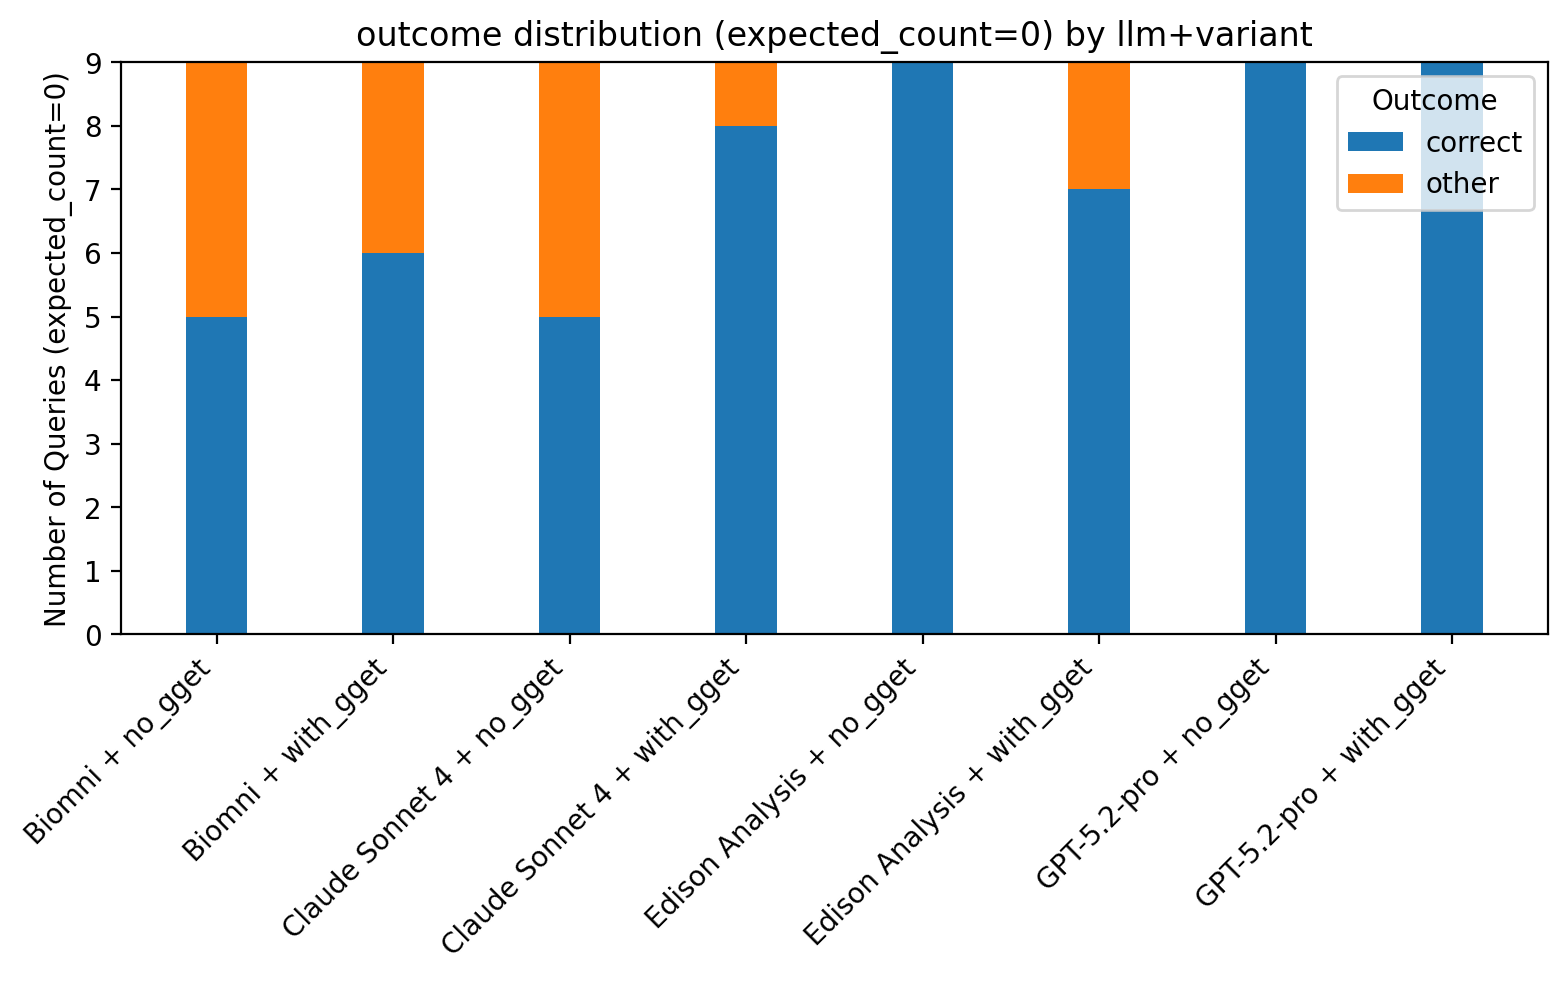

In [277]:
import matplotlib.pyplot as plt

# Filter for rows where expected_count == 0
expected_zero = results[results["expected_count"] == 0].copy()

# Group by llm, variant, and outcome, then count occurrences
counts = (
    expected_zero.groupby(["llm", "variant", "outcome"])
    .size()
    .reset_index(name="count")
)

# For each llm+variant, split 'correct'/'correct_zero' and 'other'
counts["outcome_group"] = counts["outcome"].apply(lambda x: "correct" if x in ("correct", "correct_zero") else "other")

summary = (
    counts.groupby(["llm", "variant", "outcome_group"])["count"]
    .sum()
    .reset_index()
    .pivot(index=["llm", "variant"], columns="outcome_group", values="count")
    .fillna(0)
    .reset_index()
)

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))

bar_width = 0.35
labels = summary.apply(lambda row: f"{row['llm']} + {row['variant']}", axis=1)
correct_counts = summary["correct"] if "correct" in summary else [0]*len(labels)
other_counts = summary["other"] if "other" in summary else [0]*len(labels)
x = range(len(labels))

ax.bar(x, correct_counts, bar_width, label="correct", color="tab:blue")
ax.bar(x, other_counts, bar_width, bottom=correct_counts, label="other", color="tab:orange")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Number of Queries (expected_count=0)")
ax.set_title("outcome distribution (expected_count=0) by llm+variant")
ax.legend(title="Outcome")

plt.tight_layout()
plt.show()

## Plot zero count results

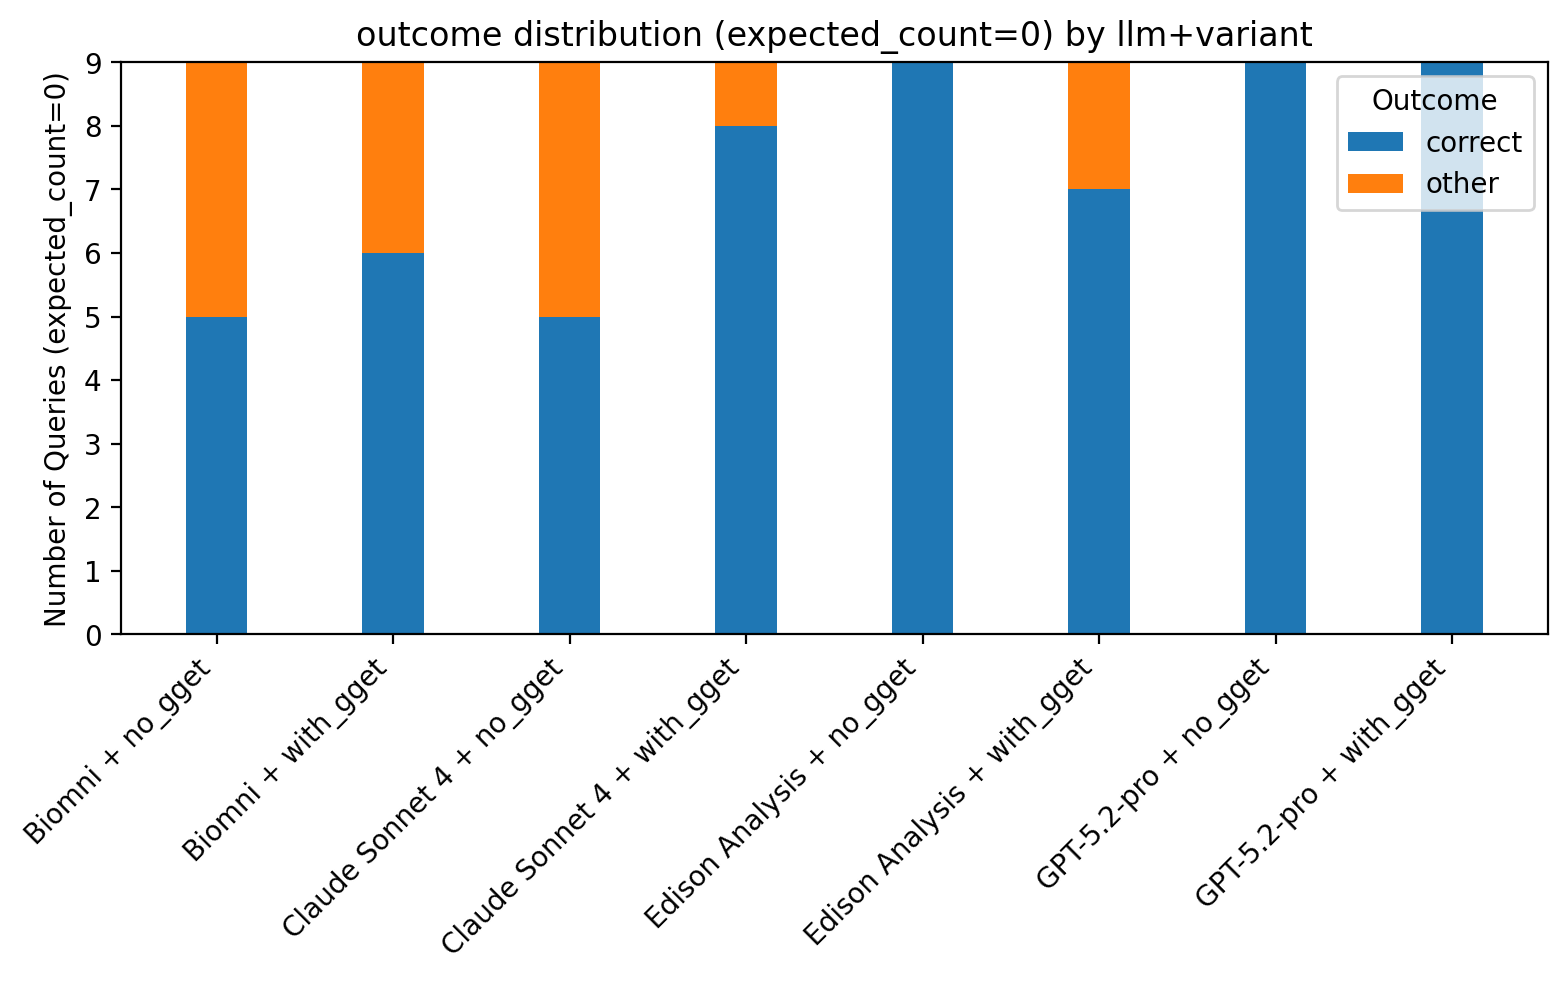

In [278]:
import matplotlib.pyplot as plt

# Filter for rows where expected_count == 0
expected_zero = results[results["expected_count"] == 0].copy()

# Group by llm, variant, and outcome, then count occurrences
counts = (
    expected_zero.groupby(["llm", "variant", "outcome"])
    .size()
    .reset_index(name="count")
)

# For each llm+variant, split 'correct' and 'other'
counts["outcome_group"] = counts["outcome"].apply(lambda x: "correct" if x == "correct_zero" else "other")

summary = (
    counts.groupby(["llm", "variant", "outcome_group"])["count"]
    .sum()
    .reset_index()
    .pivot(index=["llm", "variant"], columns="outcome_group", values="count")
    .fillna(0)
    .reset_index()
)

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))

bar_width = 0.35
labels = summary.apply(lambda row: f"{row['llm']} + {row['variant']}", axis=1)
correct_counts = summary["correct"] if "correct" in summary else [0]*len(labels)
other_counts = summary["other"] if "other" in summary else [0]*len(labels)
x = range(len(labels))

ax.bar(x, correct_counts, bar_width, label="correct", color="tab:blue")
ax.bar(x, other_counts, bar_width, bottom=correct_counts, label="other", color="tab:orange")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Number of Queries (expected_count=0)")
ax.set_title("outcome distribution (expected_count=0) by llm+variant")
ax.legend(title="Outcome")

plt.tight_layout()
plt.show()

## Queries wrong both with and without gget

Identify queries that are never correct across all 3 runs, both with and without gget, for each LLM.

In [279]:
# For each (llm, variant, query_id), compute: any run correct?
query_correct = (
    results.groupby(["llm", "variant", "query_id"])["outcome"]
    .apply(lambda x: (x == "correct").any())
    .reset_index(name="any_correct")
)

# Pivot to get no_gget / with_gget columns
pivot = query_correct.pivot_table(
    index=["llm", "query_id"], columns="variant", values="any_correct", aggfunc="first"
).reset_index()

# Queries wrong in BOTH variants
both_wrong = pivot[
    (pivot["no_gget"] == False) & (pivot["with_gget"] == False)
].copy()
both_wrong["pathogen"] = both_wrong["query_id"].map(pathogen_map).map(rename_pathogen)

print(f"Queries wrong in both variants (per LLM):")
for llm in sorted(both_wrong["llm"].unique()):
    subset = both_wrong[both_wrong["llm"] == llm]
    print(f"\n  {llm}: {len(subset)} queries")
    print(f"    Query IDs: {sorted(subset['query_id'].tolist())}")
    print(f"    Pathogens: {subset['pathogen'].value_counts().to_dict()}")

Queries wrong in both variants (per LLM):

  Biomni: 5 queries
    Query IDs: [19, 23, 43, 44, 57]
    Pathogens: {'HIV-2': 2, 'Dengue virus type 4': 1, 'HIV-1': 1, 'Mpox virus': 1}

  Claude Sonnet 4: 8 queries
    Query IDs: [19, 23, 31, 43, 44, 57, 103, 118]
    Pathogens: {'HIV-2': 2, 'Mpox virus': 2, 'Dengue virus type 4': 1, 'HIV-1': 1, 'Retroviridae': 1, 'Influenza A virus': 1}

  Edison Analysis: 4 queries
    Query IDs: [19, 23, 44, 118]
    Pathogens: {'HIV-2': 2, 'Dengue virus type 4': 1, 'Influenza A virus': 1}

  GPT-5.2-pro: 4 queries
    Query IDs: [19, 23, 44, 118]
    Pathogens: {'HIV-2': 2, 'Dengue virus type 4': 1, 'Influenza A virus': 1}


In [280]:
# Queries wrong across ALL LLMs in both variants
wrong_counts = both_wrong.groupby("query_id")["llm"].nunique().reset_index(name="n_llms_wrong")
n_llms = results["llm"].nunique()
universally_wrong = wrong_counts[wrong_counts["n_llms_wrong"] == n_llms]["query_id"].tolist()

print(f"Queries wrong across ALL {n_llms} LLMs (both with and without gget):")
for qid in sorted(universally_wrong):
    p = rename_pathogen(pathogen_map.get(qid, "?"))
    exp = configs[configs["query_id"] == qid]["expected_count"].iloc[0]
    print(f"  qid={qid}: {p}, expected={exp}")
    # Show what each LLM returned
    for llm in sorted(results["llm"].unique()):
        for variant in ["no_gget", "with_gget"]:
            sub = results[(results["llm"] == llm) & (results["variant"] == variant) & (results["query_id"] == qid)]
            counts = sub["retrieved_count"].tolist()
            outcomes = sub["outcome"].tolist()
            print(f"    {llm} ({variant}): retrieved={counts}, outcomes={outcomes}")

Queries wrong across ALL 4 LLMs (both with and without gget):
  qid=19: HIV-2, expected=0
    Biomni (no_gget): retrieved=[4.0, 0.0, 36.0], outcomes=['over_count', 'correct_zero', 'over_count']
    Biomni (with_gget): retrieved=[0.0, 41.0, 0.0], outcomes=['correct_zero', 'over_count', 'correct_zero']
    Claude Sonnet 4 (no_gget): retrieved=[41.0, 0.0, 0.0], outcomes=['over_count', 'correct_zero', 'correct_zero']
    Claude Sonnet 4 (with_gget): retrieved=[0.0, 0.0, 0.0], outcomes=['correct_zero', 'correct_zero', 'correct_zero']
    Edison Analysis (no_gget): retrieved=[0.0, 0.0, 0.0], outcomes=['correct_zero', 'correct_zero', 'correct_zero']
    Edison Analysis (with_gget): retrieved=[235.0, 0.0, 0.0], outcomes=['over_count', 'correct_zero', 'correct_zero']
    GPT-5.2-pro (no_gget): retrieved=[0.0, 0.0, 0.0], outcomes=['correct_zero', 'correct_zero', 'correct_zero']
    GPT-5.2-pro (with_gget): retrieved=[0.0, 0.0, 0.0], outcomes=['correct_zero', 'correct_zero', 'correct_zero']
  qid

## Over-counting vs under-counting

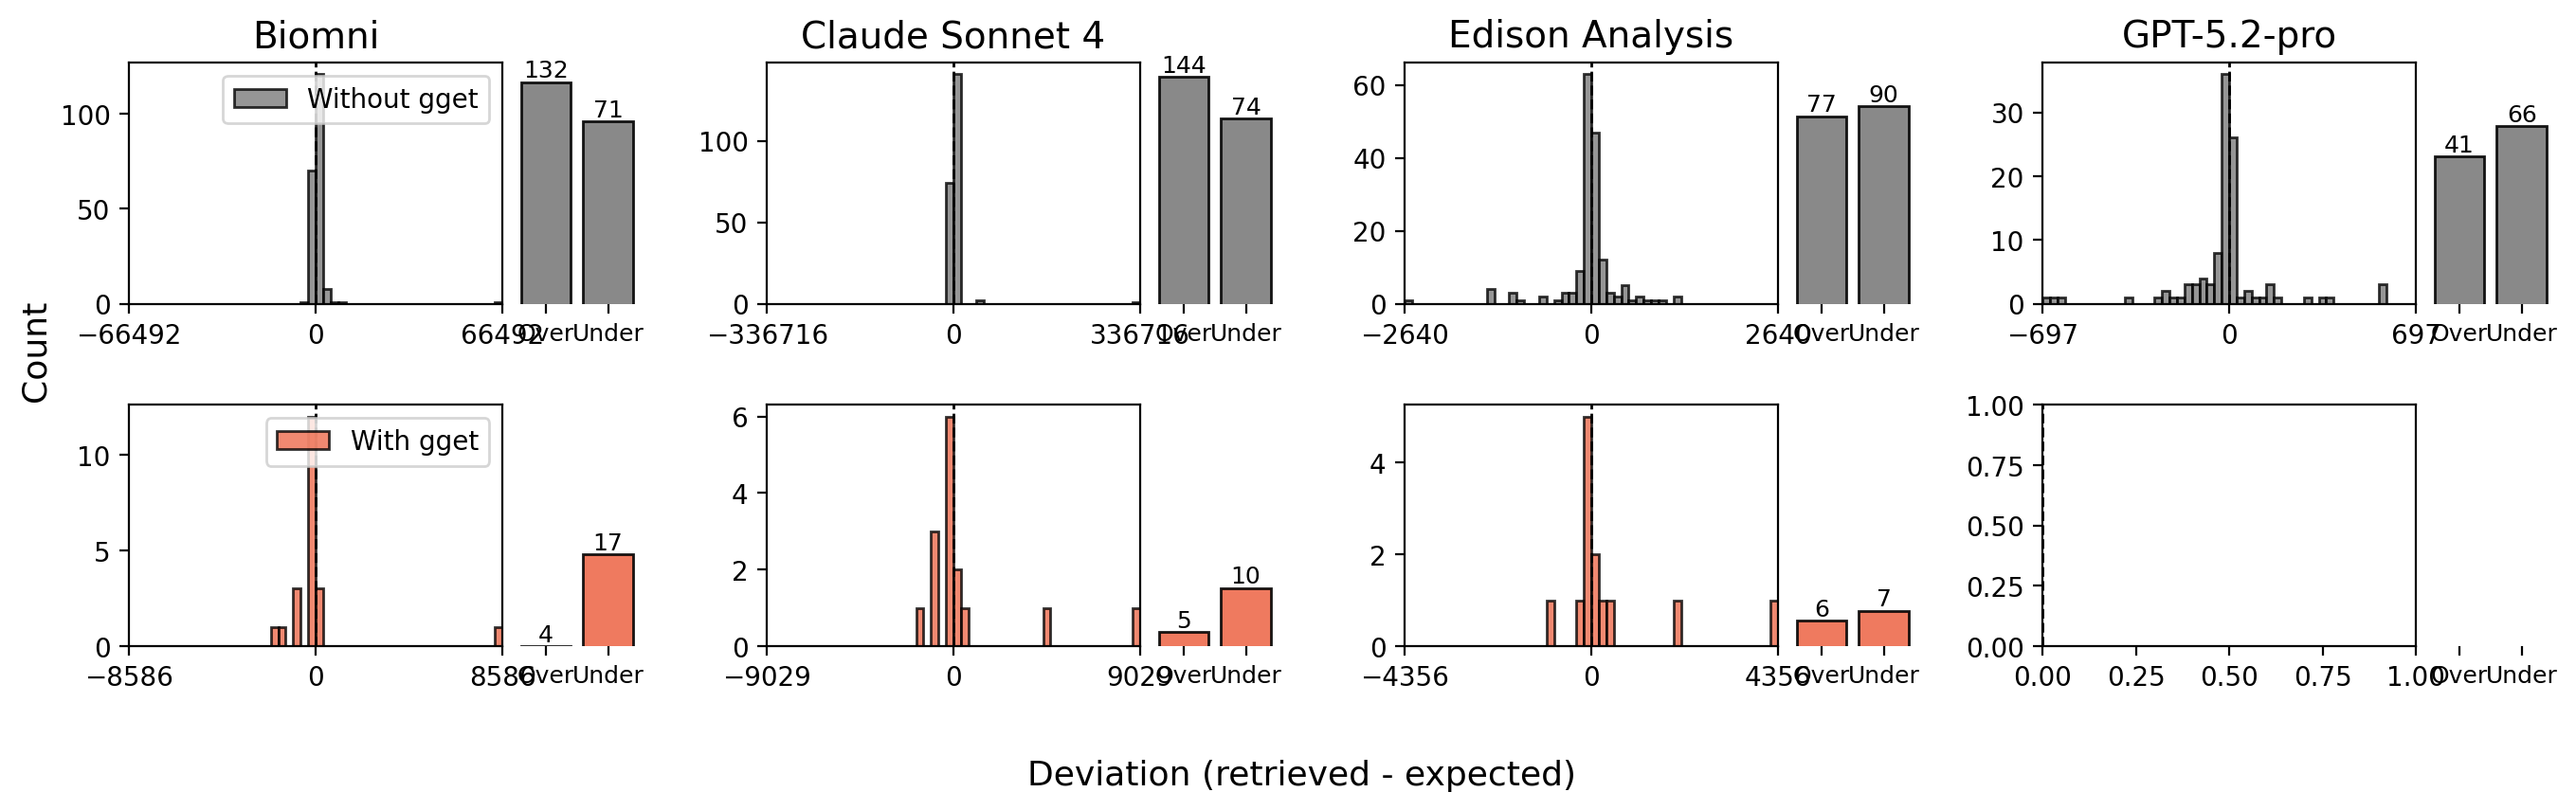

In [281]:
# Format is now:
# - Columns = LLMs/technologies
# - Top row: WITHOUT gget, Bottom row: WITH gget
# - For each LLM, left 3/4: deviation histogram; right 1/4: over/under bar plot
# - Shared x/y labels, tidy layout, figure style consistent w/ relative deviation plot below
# - Zero results (retrieved_count == 0 or NaN) are excluded from histograms
# - Added: `center_zero_on_hist` option to put 0 in the middle of the x axis
# - (Revised: x-axis min/max for histograms are now determined per technology (LLM/variant) instead of globally.)

llms = sorted(incorrect["llm"].unique())
variants = [("no_gget", "#7c7c7c", "Without gget"), ("with_gget", "#EE6C4D", "With gget")]
n_llms = len(llms)
n_variants = len(variants)

import matplotlib.gridspec as gridspec

# OPTION: Center the 0 in the histogram x-axis (so 0 is always at center, bins extend equally left/right from 0)
center_zero_on_hist = True  # <--- Set to True to put 0 in the middle

# --- First pass: compute bar plot y-limits (for symlog scale) across all LLMs/variants ---
all_bar_counts = []

for row, (variant, color, label) in enumerate(variants):
    for col, llm in enumerate(llms):
        sub = incorrect[(incorrect["llm"] == llm) & (incorrect["variant"] == variant)]
        sub_nonzero = sub[sub["retrieved_count"].notna() & (sub["retrieved_count"] != 0)]
        over_count = sub_nonzero[sub_nonzero["deviation"] > 0].shape[0]
        under_count = sub_nonzero[sub_nonzero["deviation"] < 0].shape[0]
        if over_count > 0:
            all_bar_counts.append(over_count)
        if under_count > 0:
            all_bar_counts.append(under_count)
if all_bar_counts:
    bar_ylim_min = min(all_bar_counts)
    bar_ylim_max = max(all_bar_counts)
    if bar_ylim_min <= 0:
        bar_ylim_min = 1
else:
    bar_ylim_min = 1
    bar_ylim_max = 1
bar_ylim_max_disp = int(bar_ylim_max * 1.25) if bar_ylim_max > 0 else 1

# Precompute per-LLM+variant (per-tech) min/max for the histogram x axes
hist_axis_ranges = {}
hist_bins_dict = {}
for row, (variant, color, label) in enumerate(variants):
    for col, llm in enumerate(llms):
        sub = incorrect[(incorrect["llm"] == llm) & (incorrect["variant"] == variant)]
        sub_nonzero = sub[sub["retrieved_count"].notna() & (sub["retrieved_count"] != 0)]
        devs = sub_nonzero["deviation"].dropna()
        devs = devs[np.isfinite(devs)]
        tech_key = (llm, variant)
        if len(devs) > 0 and center_zero_on_hist:
            # Make axis min/max symmetric around zero for each tech
            tech_abs_max = np.max(np.abs(devs))
            hist_min = -tech_abs_max
            hist_max = tech_abs_max
            hist_bins = np.linspace(hist_min, hist_max, 51)  # 50 bins centered on zero
            hist_axis_ranges[tech_key] = (hist_min, hist_max)
            hist_bins_dict[tech_key] = hist_bins
        elif len(devs) > 0:
            hist_min = np.min(devs)
            hist_max = np.max(devs)
            hist_axis_ranges[tech_key] = (hist_min, hist_max)
            hist_bins_dict[tech_key] = 50  # default bin count
        else:
            hist_axis_ranges[tech_key] = (-1, 1)
            hist_bins_dict[tech_key] = 51

fig = plt.figure(figsize=(16.5, 4))
outer = gridspec.GridSpec(n_variants, n_llms, wspace=0.25, hspace=0.42)

panel_axes_hist = []
panel_axes_bar = []

for row, (variant, color, label) in enumerate(variants):
    for col, llm in enumerate(llms):
        inner = gridspec.GridSpecFromSubplotSpec(
            1, 2, subplot_spec=outer[row, col], width_ratios=[3, 1], wspace=0.05
        )
        ax_hist = fig.add_subplot(inner[0,0])
        ax_bar = fig.add_subplot(inner[0,1])
        panel_axes_hist.append(ax_hist)
        panel_axes_bar.append(ax_bar)

        sub = incorrect[(incorrect["llm"] == llm) & (incorrect["variant"] == variant)]
        sub_nonzero = sub[sub["retrieved_count"].notna() & (sub["retrieved_count"] != 0)]
        devs = sub_nonzero["deviation"].dropna()
        devs = devs[np.isfinite(devs)]
        tech_key = (llm, variant)

        if len(devs) > 0:
            # Use the precomputed axis limits and bins for this LLM/variant
            hist_min, hist_max = hist_axis_ranges[tech_key]
            bins = hist_bins_dict[tech_key]
            if center_zero_on_hist:
                ax_hist.hist(
                    devs, bins=bins, alpha=0.8, color=color, label=label,
                    edgecolor="black", lw=0.5, orientation="vertical"
                )
                ax_hist.set_xlim(hist_min, hist_max)
                ax_hist.set_xticks([hist_min, 0, hist_max])
            else:
                ax_hist.hist(
                    devs, bins=bins, alpha=0.8, color=color, label=label,
                    edgecolor="black", lw=0.5, orientation="vertical"
                )
                ax_hist.set_xlim(hist_min, hist_max)
        ax_hist.axvline(0, color="black", ls="--", lw=1)
        ax_hist.set_xlabel("")
        ax_hist.set_ylabel("")
        if row == 0:
            ax_hist.set_title(llm, fontsize=FONTSIZE + 2)
        if col == 0:
            ax_hist.legend(fontsize=FONTSIZE - 2, loc="upper right")

        # Bar plot: show counts of over/under (excluding zero results)
        over_count = sub_nonzero[sub_nonzero["deviation"] > 0].shape[0]
        under_count = sub_nonzero[sub_nonzero["deviation"] < 0].shape[0]
        bar_vals = [over_count, under_count]
        bar_colors = ["#7c7c7c", "#7c7c7c"] if row == 0 else ["#EE6C4D", "#EE6C4D"]
        ax_bar.bar(
            ["Over", "Under"], bar_vals, color=bar_colors, edgecolor="black", alpha=0.9
        )
        ax_bar.set_xticks([0,1])
        ax_bar.set_xticklabels(["Over", "Under"], rotation=0, fontsize=FONTSIZE-3)
        ax_bar.set_yscale("symlog")
        ax_bar.tick_params(axis='y', labelleft=False, left=False)
        ax_bar.set_xlim(-0.5, 1.5)
        ax_bar.set_ylim(bar_ylim_min, bar_ylim_max_disp)
        ax_bar.set_xlabel("")
        ax_bar.set_ylabel("")
        for label in ax_bar.get_yticklabels():
            label.set_visible(False)
        for spine in ["top", "bottom", "left", "right"]:
            ax_bar.spines[spine].set_visible(False)
        ax_bar.grid(False)
        for x, val in enumerate(bar_vals):
            if val > 0:
                ax_bar.text(x, val, f"{val}", ha='center', va='bottom', fontsize=FONTSIZE-3)

fig.text(0.5, -0.06, "Deviation (retrieved - expected)", ha='center', va='center', fontsize=FONTSIZE + 1)
fig.text(0.095, 0.5, "Count", ha='center', va='center', rotation='vertical', fontsize=FONTSIZE + 1)
fig.savefig("../figures/deviation_histograms.png", bbox_inches="tight", dpi=300)
plt.show()

Zero results are not included here, hence no results for GPT + gget.

In [282]:
# Summary table: fraction of incorrect runs that over-count vs under-count
incorrect_no_zero = results[results["outcome"].isin(["over_count", "under_count"])].copy()

summary = (
    incorrect_no_zero.groupby(["llm", "variant", "outcome"])
    .size()
    .unstack(fill_value=0)
)
summary["total"] = summary.sum(axis=1)
summary["pct_over"] = (summary["over_count"] / summary["total"] * 100).round(1)
summary["pct_under"] = (summary["under_count"] / summary["total"] * 100).round(1)
print("Over-count vs under-count (excluding zeros and errors):")
print(summary)

print("\nMedian deviation when wrong (excluding zeros):")
for llm in sorted(incorrect_no_zero["llm"].unique()):
    for variant in ["no_gget", "with_gget"]:
        sub = incorrect_no_zero[(incorrect_no_zero["llm"] == llm) & (incorrect_no_zero["variant"] == variant)]
        if not sub.empty:
            print(f"  {llm} ({variant}): median={sub['deviation'].median():.0f}, mean={sub['deviation'].mean():.1f}")

Over-count vs under-count (excluding zeros and errors):
outcome                    over_count  under_count  total  pct_over  pct_under
llm             variant                                                       
Biomni          no_gget           132           71    203      65.0       35.0
                with_gget           4           17     21      19.0       81.0
Claude Sonnet 4 no_gget           144           74    218      66.1       33.9
                with_gget           5           10     15      33.3       66.7
Edison Analysis no_gget            77           90    167      46.1       53.9
                with_gget           6            7     13      46.2       53.8
GPT-5.2-pro     no_gget            41           66    107      38.3       61.7

Median deviation when wrong (excluding zeros):
  Biomni (no_gget): median=8, mean=603.3
  Biomni (with_gget): median=-13, mean=122.3
  Claude Sonnet 4 (no_gget): median=17, mean=2349.6
  Claude Sonnet 4 (with_gget): median=-32, mean

In [283]:
# Runs where retrieved - expected > 10,000
threshold = 10_000
big_over = results[
    (results["retrieved_count"] - results["expected_count"]) > threshold
].copy()
big_over["deviation"] = big_over["retrieved_count"] - big_over["expected_count"]
big_over["tech"] = big_over["llm"] + " (" + big_over["variant"] + ")"

print(f"Runs with retrieved - expected > {threshold:,}: {len(big_over)}\n")
for tech, group in big_over.groupby("tech"):
    print(f"── {tech} ──")
    for _, row in group.sort_values("deviation", ascending=False).iterrows():
        print(f"  query_id={int(row['query_id']):>3d}  run={int(row['run_number'])}  "
              f"expected={int(row['expected_count']):>7,}  "
              f"retrieved={int(row['retrieved_count']):>7,}  "
              f"Δ={int(row['deviation']):>+8,}  "
              f"pathogen={row['pathogen']}")
    print()

Runs with retrieved - expected > 10,000: 6

── Biomni (no_gget) ──
  query_id= 59  run=3  expected=    304  retrieved= 66,796  Δ= +66,492  pathogen=Influenza A virus

── Claude Sonnet 4 (no_gget) ──
  query_id= 59  run=3  expected=    304  retrieved=337,020  Δ=+336,716  pathogen=Influenza A virus
  query_id= 89  run=1  expected=      1  retrieved= 50,192  Δ= +50,191  pathogen=NC_105106.1
  query_id= 89  run=3  expected=      1  retrieved= 50,192  Δ= +50,191  pathogen=NC_105106.1
  query_id=108  run=1  expected=      1  retrieved= 11,562  Δ= +11,561  pathogen=MT666073.1
  query_id=108  run=2  expected=      1  retrieved= 11,562  Δ= +11,561  pathogen=MT666073.1



In [284]:
import pprint
# Path to the JSON file
json_path = "/Users/laura/Documents/FutureHouse/VirBench/results/edison_analysis/benchmark_report_gv_20260227_113028_rerun_20260302_094332.json"

# Load the JSON as a dict
with open(json_path, "r") as f:
    data = json.load(f)

# The format may be a dict with a list of entries--let's inspect for query_id=58 and run=2
raw_response_found = False
for entry in data.get("results", data):
    # Try both possible keys for run/run_number
    if (
        str(entry.get("query_id")) == "58"
        and str(entry.get("run_number", entry.get("run"))) == "2"
    ):
        print("raw_response for query_id=58, run=2:")
        pprint.pprint(entry.get("raw_response"))
        raw_response_found = True
        break

if not raw_response_found:
    print("No entry with query_id=58 and run=2 found in the JSON.")


raw_response for query_id=58, run=2:
('[FinchTaskResponse(status=\'success\', query="Use the gget virus module '
 "installable with 'pip install --upgrade gget'. The documentation is "
 'attached. Retrieve viral sequences from NCBI for TaxID 10407 (Hepatitis B '
 'virus (HBV)) that adhere to the following criteria: collected on or after '
 '2020-01-01, collected on or before 2025-12-31, released on or after '
 '2020-01-01, released on or before 2025-12-31, minimum sequence length: 3000 '
 "bp, maximum 10 ambiguous characters (N's) . Return only the count of "
 'sequences that match these criteria.", user=\'lluebbert@futurehouse.org\', '
 'created_at=datetime.datetime(2026, 2, 28, 6, 32, 35, 989088, '
 "tzinfo=TzInfo(0)), job_name='job-futurehouse-data-analysis-crow-high', "
 "share_status='private', permitted_accessors={'users': [], 'organizations': "
 "[]}, build_owner='FutureHouse', environment_name=None, agent_name=None, "
 "task_id=UUID('7b877bff-76ea-4136-9092-d80c93ac6b4a'), proj

## Outcome breakdown by LLM and variant

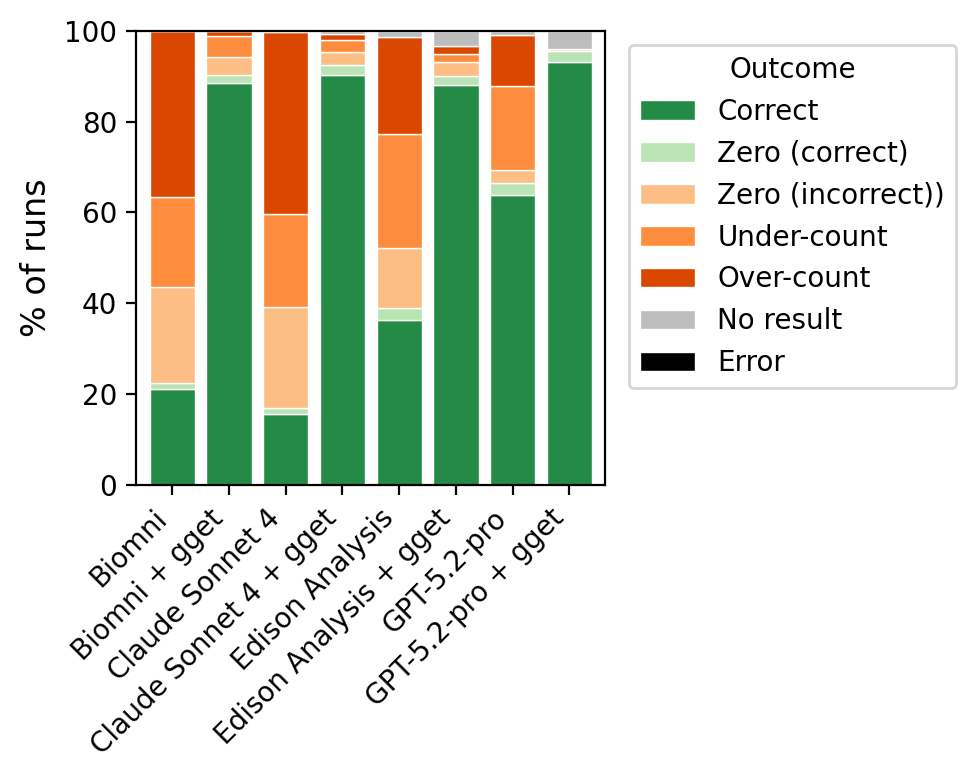

In [285]:
# Stacked bar chart of outcome categories per LLM x variant
outcome_order = ["correct", "correct_zero", "zero", "under_count", "over_count", "no_result", "error"]
outcome_colors = {
    "correct": "#238b45",
    "correct_zero": "#bae4b3",
    "zero": "#fdbe85",
    "under_count": "#fd8d3c",
    "over_count": "#d94701",
    "no_result": "#BDBDBD",
    "error": "black",
}
outcome_labels = {
    "correct": "Correct",
    "correct_zero": "Zero (correct)",
    "zero": "Zero (incorrect))",
    "over_count": "Over-count",
    "under_count": "Under-count",
    "no_result": "No result",
    "error": "Error",
}

llms = sorted(results["llm"].unique())
variants = ["no_gget", "with_gget"]
labels = []
for llm in llms:
    labels.append(f"{llm}")
    labels.append(f"{llm} + gget")

fig, ax = plt.subplots(figsize=(5, 4))
x = np.arange(len(labels))
bottom = np.zeros(len(labels))

for outcome in outcome_order:
    heights = []
    for llm in llms:
        for variant in variants:
            sub = results[(results["llm"] == llm) & (results["variant"] == variant)]
            total = len(sub)
            count = (sub["outcome"] == outcome).sum()
            heights.append(count / total * 100 if total > 0 else 0)
    heights = np.array(heights)
    ax.bar(x, heights, bottom=bottom, color=outcome_colors[outcome],
           label=outcome_labels[outcome], edgecolor="white", lw=0.5)
    bottom += heights

ax.margins(x=0.03)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=FONTSIZE - 2, rotation=45, ha="right")
ax.set_ylabel("% of runs", fontsize=FONTSIZE)
# ax.set_title("Outcome distribution per LLM and variant", fontsize=FONTSIZE + 2)
ax.legend(title="Outcome", title_fontsize=FONTSIZE - 2, fontsize=FONTSIZE - 2, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig("../figures/outcome_distribution.png", bbox_inches="tight", dpi=300)
plt.show()

## Failure modes per virus

/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_74682/150630021.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


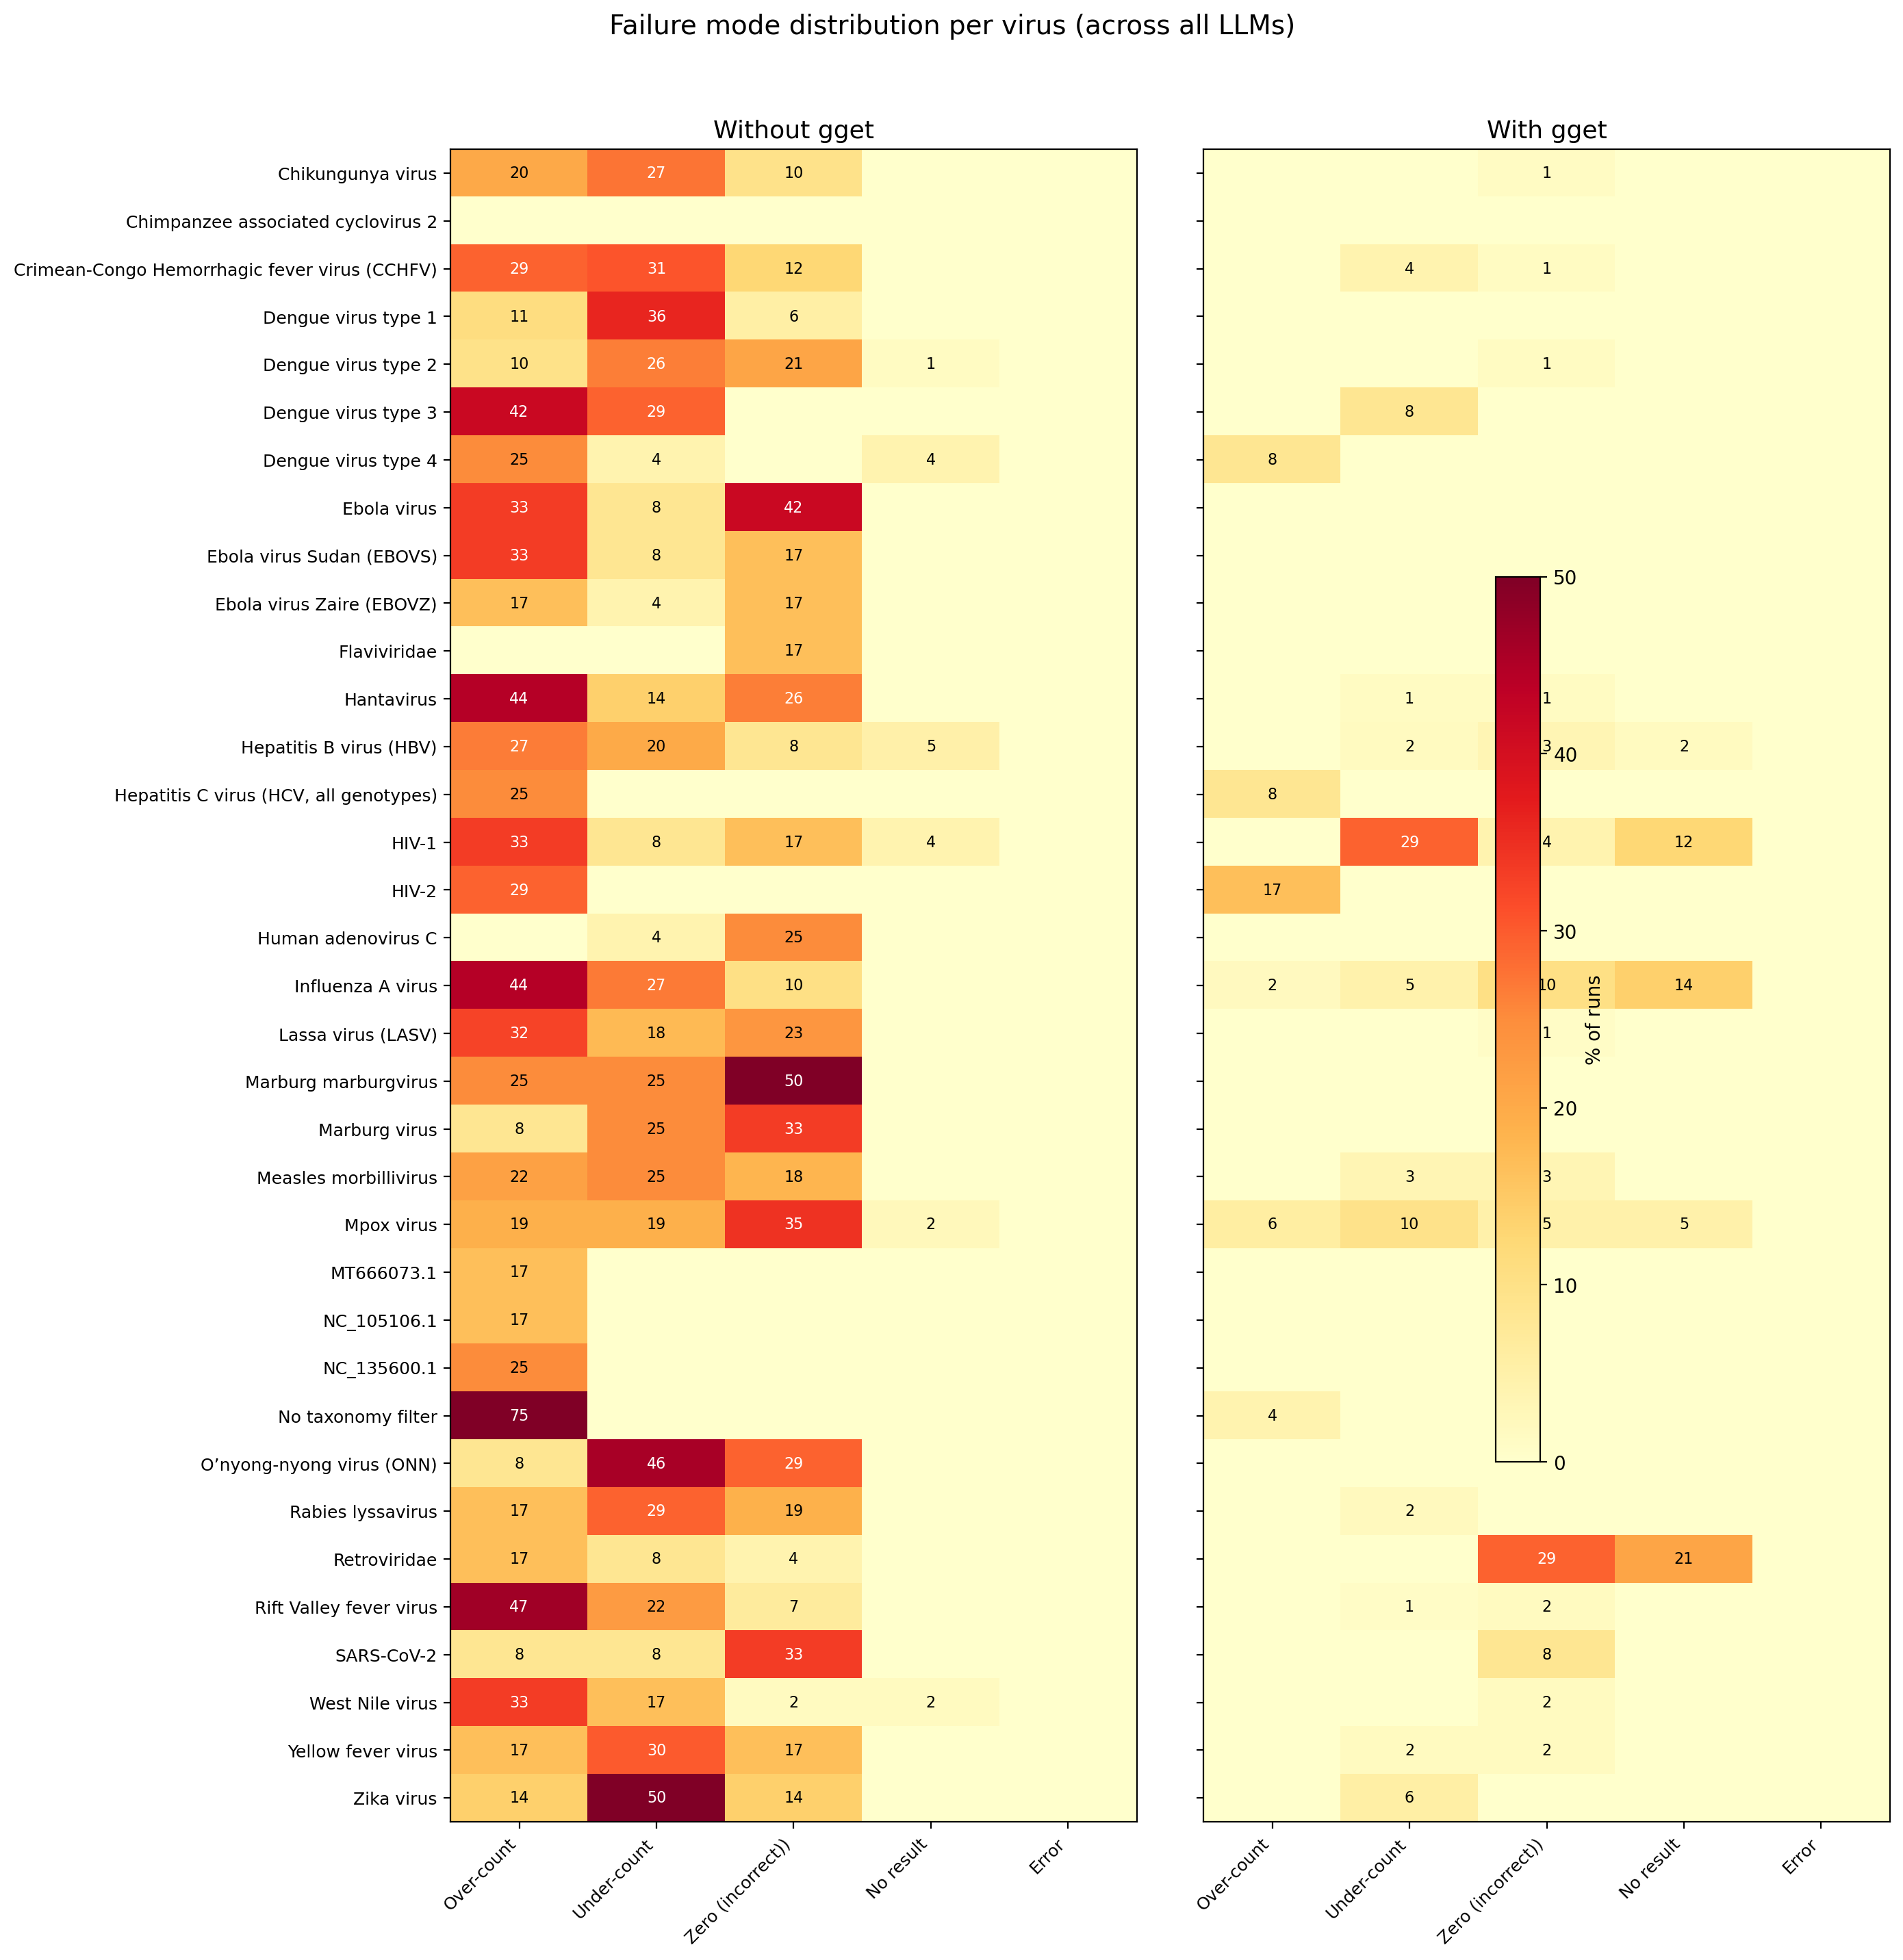

In [286]:
# Heatmap: fraction of runs that are incorrect, per pathogen x LLM (aggregating both variants)
pathogens = sorted(results["pathogen"].dropna().unique(), key=str.lower)

# Dominant failure mode per pathogen (across all LLMs and variants)
wrong_runs = results[results["outcome"] != "correct"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(pathogens) * 0.4)),
                         gridspec_kw={"width_ratios": [1, 1]})

for ax, variant, title in zip(axes, ["no_gget", "with_gget"], ["Without gget", "With gget"]):
    sub = results[results["variant"] == variant]
    # Build matrix: rows = pathogens, cols = outcome categories (excluding correct)
    fail_outcomes = ["over_count", "under_count", "zero", "no_result", "error"]
    matrix = np.zeros((len(pathogens), len(fail_outcomes)))
    for i, p in enumerate(pathogens):
        p_sub = sub[sub["pathogen"] == p]
        total = len(p_sub)
        if total == 0:
            matrix[i, :] = np.nan
            continue
        for j, outcome in enumerate(fail_outcomes):
            matrix[i, j] = (p_sub["outcome"] == outcome).sum() / total * 100

    im = ax.imshow(matrix, aspect="auto", cmap="YlOrRd", vmin=0, vmax=50)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = matrix[i, j]
            if np.isnan(val) or val == 0:
                continue
            ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                    fontsize=FONTSIZE - 4, color="white" if val > 25 else "black")

    ax.set_yticks(range(len(pathogens)))
    if ax == axes[0]:
        ax.set_yticklabels([p[0].upper() + p[1:] for p in pathogens], fontsize=FONTSIZE - 3)
    else:
        ax.set_yticklabels([])
    ax.set_xticks(range(len(fail_outcomes)))
    ax.set_xticklabels([outcome_labels[o] for o in fail_outcomes],
                       fontsize=FONTSIZE - 3, rotation=45, ha="right")
    ax.set_title(title, fontsize=FONTSIZE + 1)

fig.colorbar(im, ax=axes, label="% of runs", shrink=0.6, pad=0.02)
fig.suptitle("Failure mode distribution per virus (across all LLMs)", fontsize=FONTSIZE + 2, y=1.02)
fig.tight_layout()
plt.show()

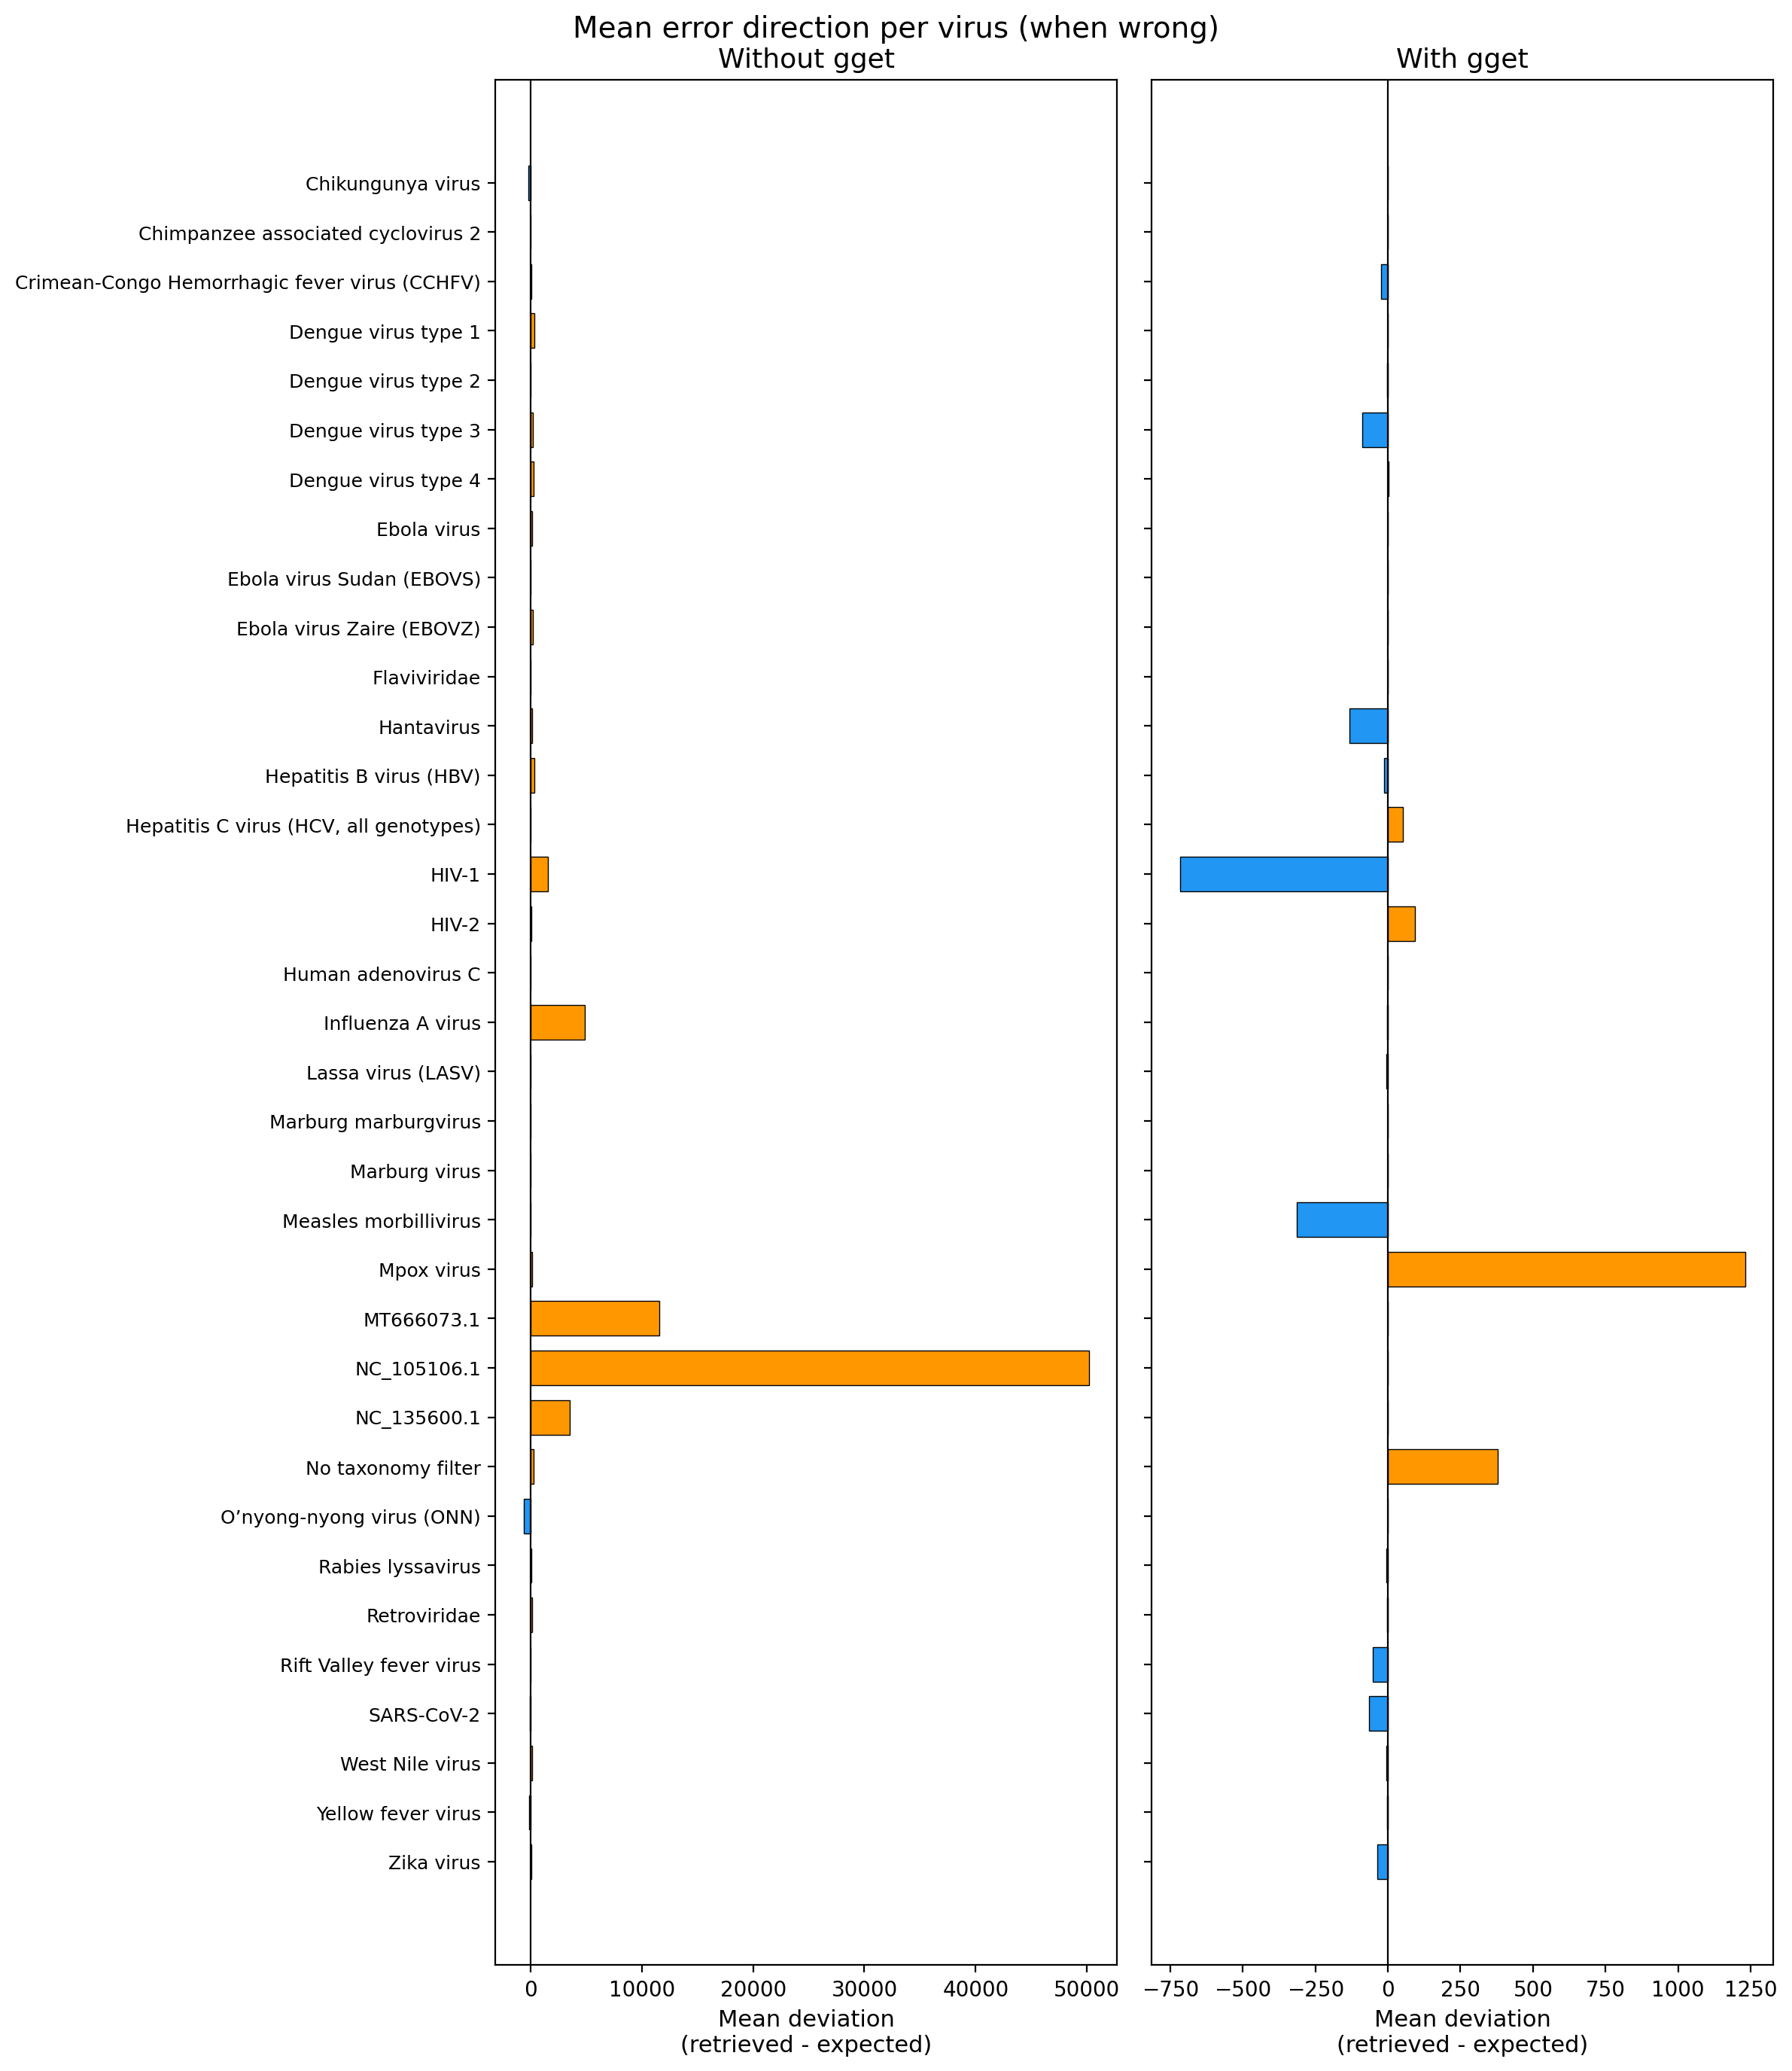

In [287]:
# Per pathogen: mean deviation (retrieved - expected) when wrong
wrong_with_counts = results[
    results["outcome"].isin(["over_count", "under_count", "zero"])
].copy()

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, max(4, len(pathogens) * 0.4)),
                                sharey=True)

for ax, variant, title in zip([ax0, ax1], ["no_gget", "with_gget"], ["Without gget", "With gget"]):
    sub = wrong_with_counts[wrong_with_counts["variant"] == variant]
    means = []
    for p in pathogens:
        p_sub = sub[sub["pathogen"] == p]
        means.append(p_sub["deviation"].mean() if len(p_sub) > 0 else 0)

    colors = ["#FF9800" if m > 0 else "#2196F3" for m in means]
    y = np.arange(len(pathogens))
    ax.barh(y, means, color=colors, edgecolor="black", lw=0.5, height=0.7)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(title, fontsize=FONTSIZE + 1)
    ax.set_xlabel("Mean deviation\n(retrieved - expected)", fontsize=FONTSIZE - 1)

ax0.set_yticks(y)
ax0.set_yticklabels([p[0].upper() + p[1:] for p in pathogens], fontsize=FONTSIZE - 3)
ax0.invert_yaxis()

fig.suptitle("Mean error direction per virus (when wrong)", fontsize=FONTSIZE + 2)
fig.tight_layout()
plt.show()

## Reasoning analysis from JSON reports

Examine the reasoning and methods from the detailed JSON reports for persistently wrong queries.

In [288]:
# Merge reasoning into results for wrong queries
merged = results.merge(
    reports[["llm", "variant", "query_id", "run_number", "reasoning", "methods", "raw_response"]],
    on=["llm", "variant", "query_id", "run_number"],
    how="left"
)

# Focus on queries wrong in BOTH variants for each LLM
persistent_qids = both_wrong[["llm", "query_id"]].drop_duplicates()
persistent_results = merged.merge(persistent_qids, on=["llm", "query_id"])

print(f"Persistent failures with reasoning data: {persistent_results['reasoning'].notna().sum()} / {len(persistent_results)} rows")
print()

Persistent failures with reasoning data: 68 / 126 rows



In [289]:
# Show reasoning for a sample of persistently wrong queries
# Pick queries wrong across the most LLMs
worst_qids = (
    both_wrong.groupby("query_id")["llm"].nunique()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

for qid in worst_qids:
    p = rename_pathogen(pathogen_map.get(qid, "?"))
    cfg = configs[configs["query_id"] == qid].iloc[0]
    exp = cfg["expected_count"]

    # Build query description from config columns
    filters = []
    for col in ["host", "nuc_completeness", "geographic_location", "submitter_country",
                "min_collection_date", "max_collection_date", "min_release_date", "max_release_date",
                "min_seq_length", "max_seq_length", "max_ambiguous_chars", "lineage",
                "source_database", "segment"]:
        val = cfg[col] if col in cfg.index else None
        if val is not None and pd.notna(val) and str(val).strip() != "":
            filters.append(f"{col}={val}")

    print(f"\n{'='*80}")
    print(f"Query {qid}: {p} (expected={exp})")
    print(f"  Filters: {', '.join(filters)}")
    n_llms_wrong_here = both_wrong[both_wrong["query_id"] == qid]["llm"].nunique()
    print(f"  Wrong across {n_llms_wrong_here}/{n_llms} LLMs in both variants")

    # Show outcomes and reasoning per LLM
    for llm in sorted(results["llm"].unique()):
        for variant in ["no_gget", "with_gget"]:
            sub = persistent_results[
                (persistent_results["llm"] == llm) &
                (persistent_results["variant"] == variant) &
                (persistent_results["query_id"] == qid)
            ]
            if sub.empty:
                continue
            counts = sub["retrieved_count"].tolist()
            outcomes = sub["outcome"].tolist()
            print(f"\n  {llm} ({variant}): retrieved={counts}, outcomes={outcomes}")
            # Show reasoning from first run if available
            first = sub.iloc[0]
            reasoning = first.get("reasoning")
            if reasoning is not None and (not isinstance(reasoning, float) or not np.isnan(reasoning)):
                if isinstance(reasoning, list):
                    for step in reasoning:
                        print(f"    - {step}")
                else:
                    print(f"    Reasoning: {str(reasoning)[:500]}")


Query 19: HIV-2 (expected=0)
  Filters: geographic_location=Africa, min_collection_date=2020-01-01, max_collection_date=2025-12-31, min_release_date=2020-01-01, max_release_date=2025-12-31, min_seq_length=9000.0, max_ambiguous_chars=10.0
  Wrong across 4/4 LLMs in both variants

  Biomni (no_gget): retrieved=[4.0, 0.0, 36.0], outcomes=['over_count', 'correct_zero', 'over_count']

  Biomni (with_gget): retrieved=[0.0, 41.0, 0.0], outcomes=['correct_zero', 'over_count', 'correct_zero']

  Claude Sonnet 4 (no_gget): retrieved=[41.0, 0.0, 0.0], outcomes=['over_count', 'correct_zero', 'correct_zero']
    - Used NCBI E-utilities with TaxID 11709 for HIV-2, length filter ≥9000bp, and publication date 2020-2025
    - Filtered by Africa geographic location using keyword matching in sequence titles (all from Senegal)
    - Applied final filter for ≤10 ambiguous characters by analyzing FASTA sequences - all had 0 N's

  Claude Sonnet 4 (with_gget): retrieved=[0.0, 0.0, 0.0], outcomes=['correct_z

## Methods used in failed queries

What APIs/tools do LLMs use when they get the wrong answer?

In [290]:
# Count methods used in wrong vs correct runs
merged_with_outcome = merged[merged["methods"].notna()].copy()

def explode_methods(df):
    rows = []
    for _, row in df.iterrows():
        methods = row["methods"]
        if isinstance(methods, list):
            for m in methods:
                rows.append({"method": m, "outcome": row["outcome"], "llm": row["llm"], "variant": row["variant"]})
    return pd.DataFrame(rows)

method_df = explode_methods(merged_with_outcome)
if not method_df.empty:
    print("Methods used in CORRECT vs WRONG runs:")
    method_df["is_correct"] = method_df["outcome"] == "correct"
    method_counts = method_df.groupby(["method", "is_correct"]).size().unstack(fill_value=0)
    method_counts.columns = ["wrong", "correct"]
    method_counts["total"] = method_counts.sum(axis=1)
    method_counts["pct_correct"] = (method_counts["correct"] / method_counts["total"] * 100).round(1)
    print(method_counts.sort_values("total", ascending=False).to_string())
else:
    print("No methods data available in JSON reports.")

Methods used in CORRECT vs WRONG runs:
                                                                                                                                                                                                                                                                                 wrong  correct  total  pct_correct
method                                                                                                                                                                                                                                                                                                             
pip install --upgrade gget                                                                                                                                                                                                                                                           1      100    101         99.0
NCBI Entrez API via BioPython        

## Impact of adding gget: which queries changed outcome?

In [291]:
# Per query, compare majority outcome with vs without gget
def majority_outcome(group):
    return group["outcome"].mode().iloc[0] if len(group) > 0 else None

query_outcomes = (
    results.groupby(["llm", "variant", "query_id"])
    .apply(majority_outcome)
    .reset_index(name="majority_outcome")
)

pivot_outcomes = query_outcomes.pivot_table(
    index=["llm", "query_id"], columns="variant", values="majority_outcome", aggfunc="first"
).reset_index()
pivot_outcomes["pathogen"] = pivot_outcomes["query_id"].map(pathogen_map).map(rename_pathogen)

# Transition matrix: no_gget outcome -> with_gget outcome
print("Outcome transitions (no_gget -> with_gget), aggregated across all LLMs:")
transition = pd.crosstab(
    pivot_outcomes["no_gget"], pivot_outcomes["with_gget"],
    margins=True
)
print(transition)

print("\n--- Queries that got WORSE with gget (correct -> wrong): ---")
got_worse = pivot_outcomes[
    (pivot_outcomes["no_gget"] == "correct") & (pivot_outcomes["with_gget"] != "correct")
]
print(f"Total: {len(got_worse)}")
if not got_worse.empty:
    print(got_worse.groupby(["llm", "with_gget"]).size().reset_index(name="count").to_string(index=False))

print("\n--- Queries that got BETTER with gget (wrong -> correct): ---")
got_better = pivot_outcomes[
    (pivot_outcomes["no_gget"] != "correct") & (pivot_outcomes["with_gget"] == "correct")
]
print(f"Total: {len(got_better)}")
if not got_better.empty:
    print(got_better.groupby(["llm", "no_gget"]).size().reset_index(name="count").to_string(index=False))

Outcome transitions (no_gget -> with_gget), aggregated across all LLMs:
with_gget     correct  correct_zero  no_result  over_count  under_count  zero  \
no_gget                                                                         
correct           173             0          3           0            0     5   
correct_zero        0            10          0           0            0     0   
no_result           2             0          1           0            0     0   
over_count        135             2          3           1            2     1   
under_count        77             0          2           0            1     1   
zero               60             0          0           0            1     0   
All               447            12          9           1            4     7   

with_gget     All  
no_gget            
correct       181  
correct_zero   10  
no_result       3  
over_count    144  
under_count    81  
zero           61  
All           480  

--- Queries that 

## Failure modes per virus, per LLM

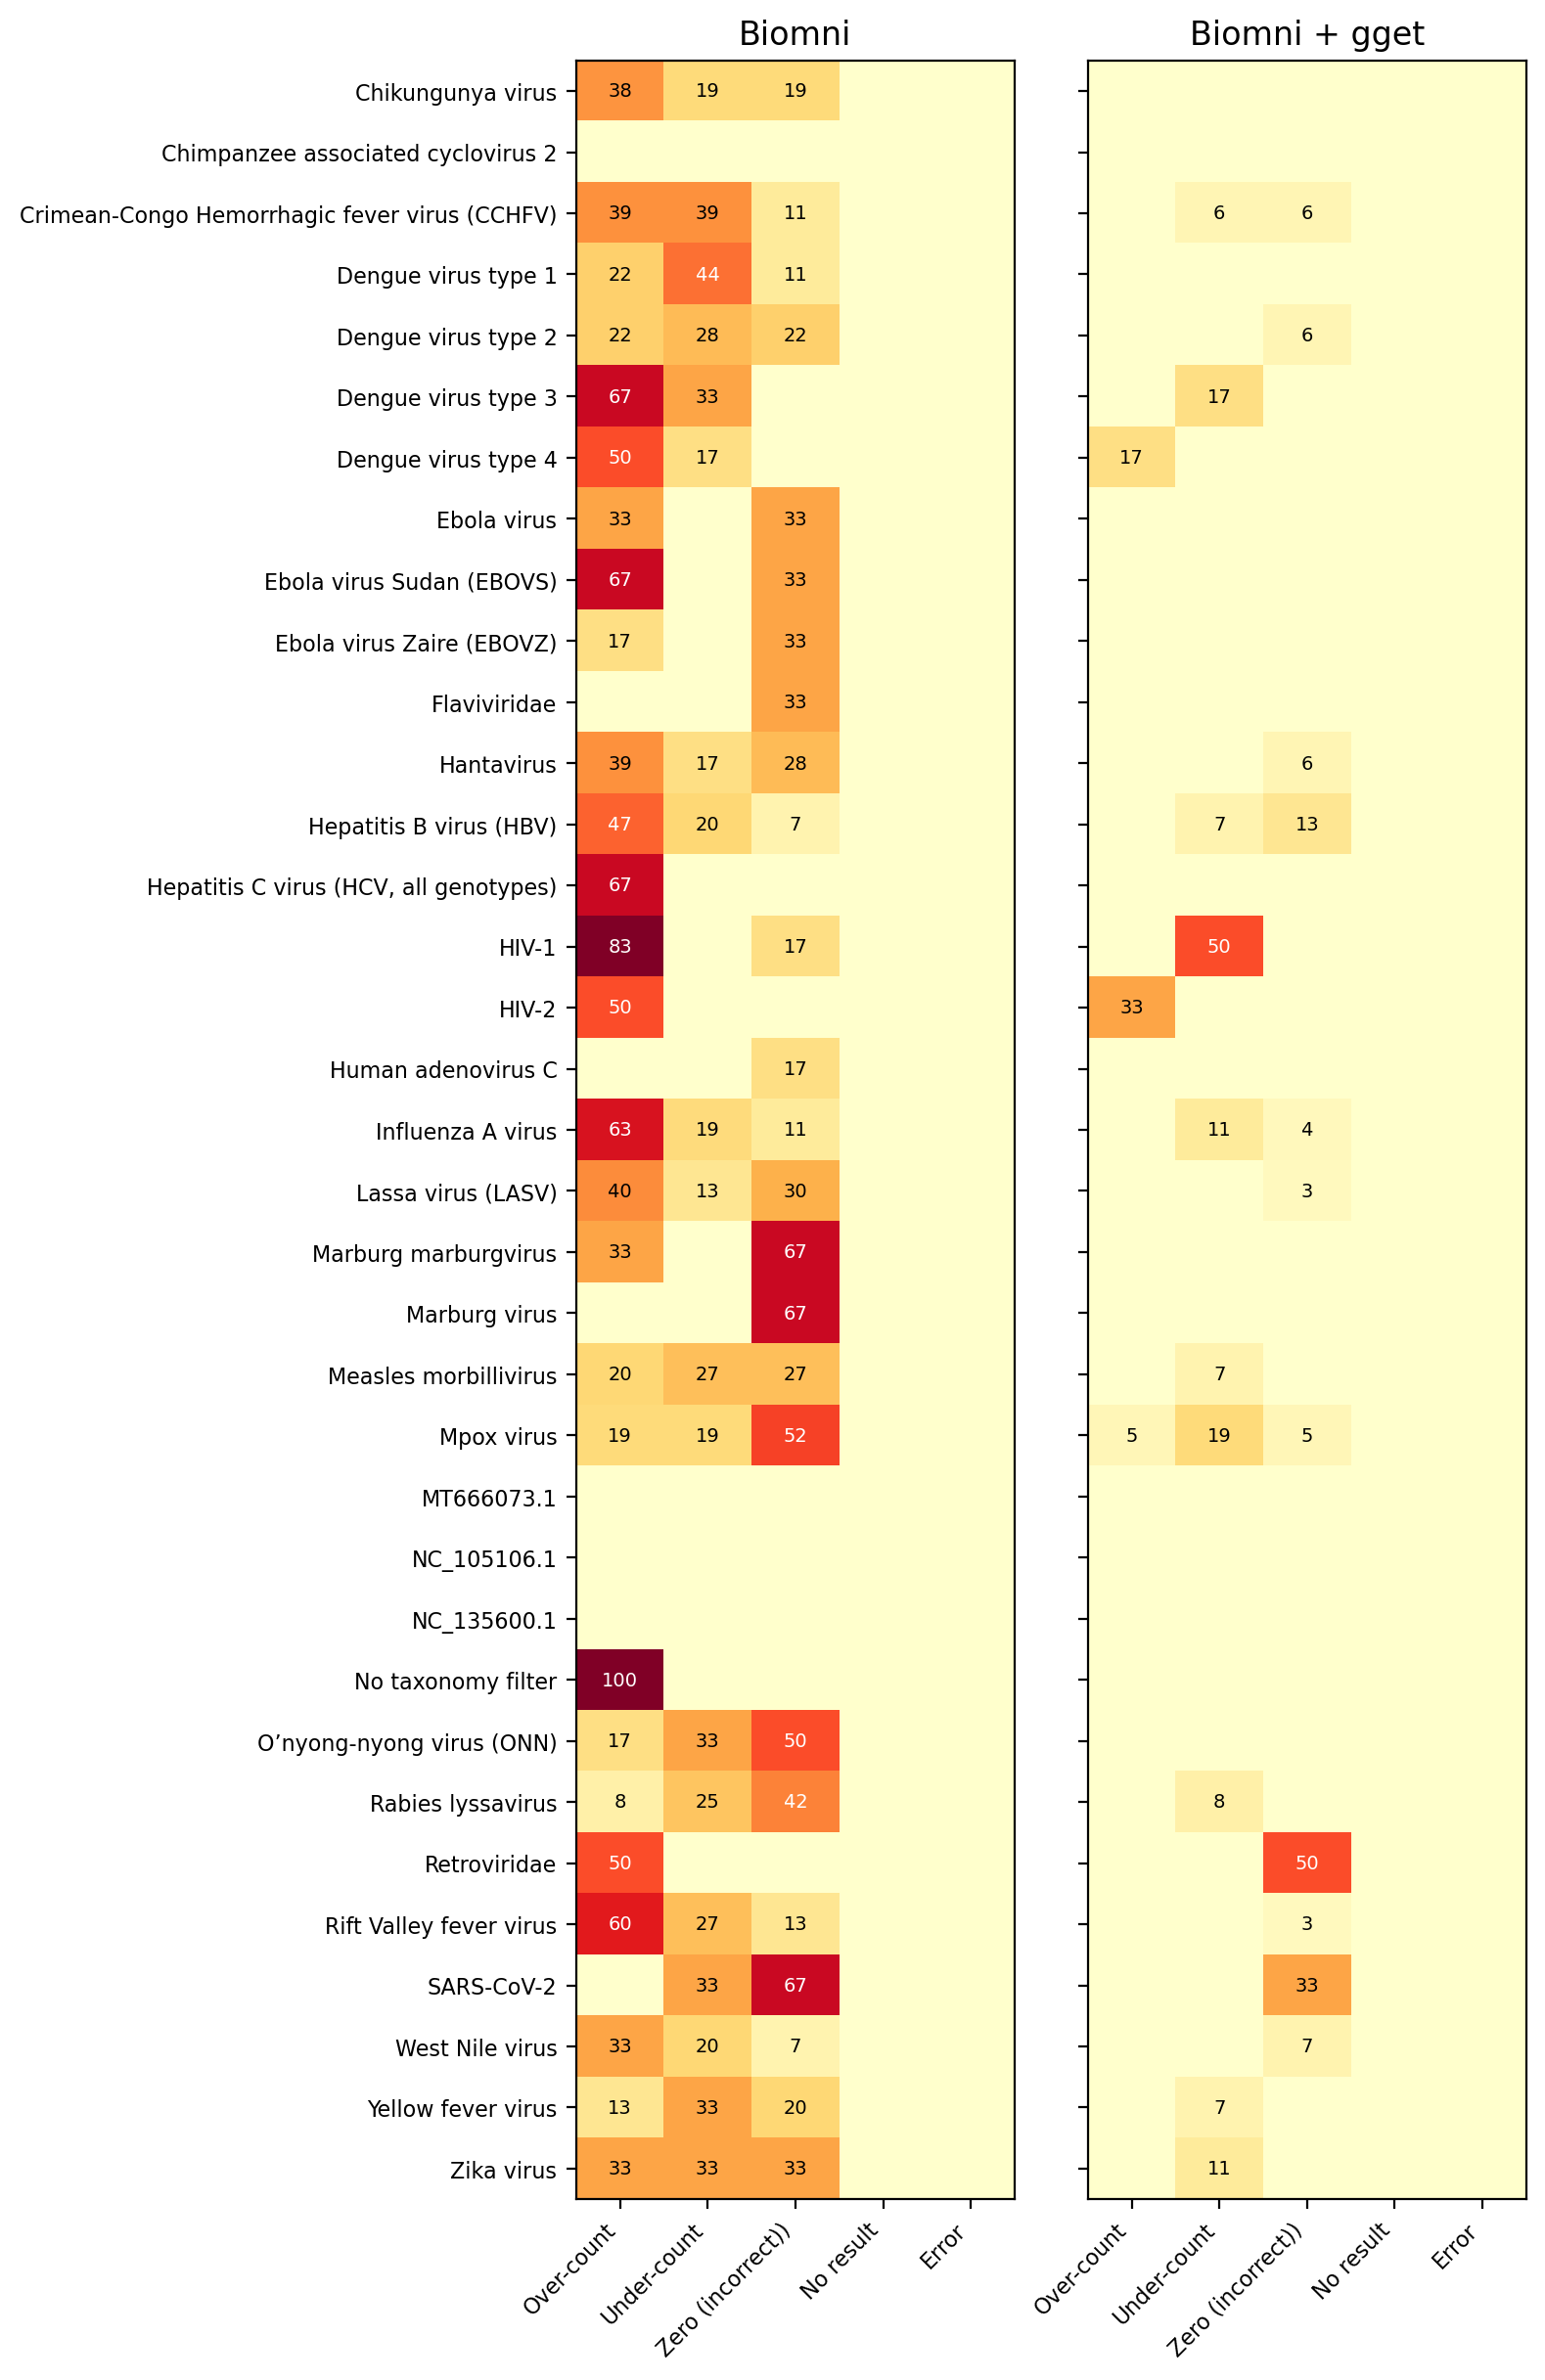

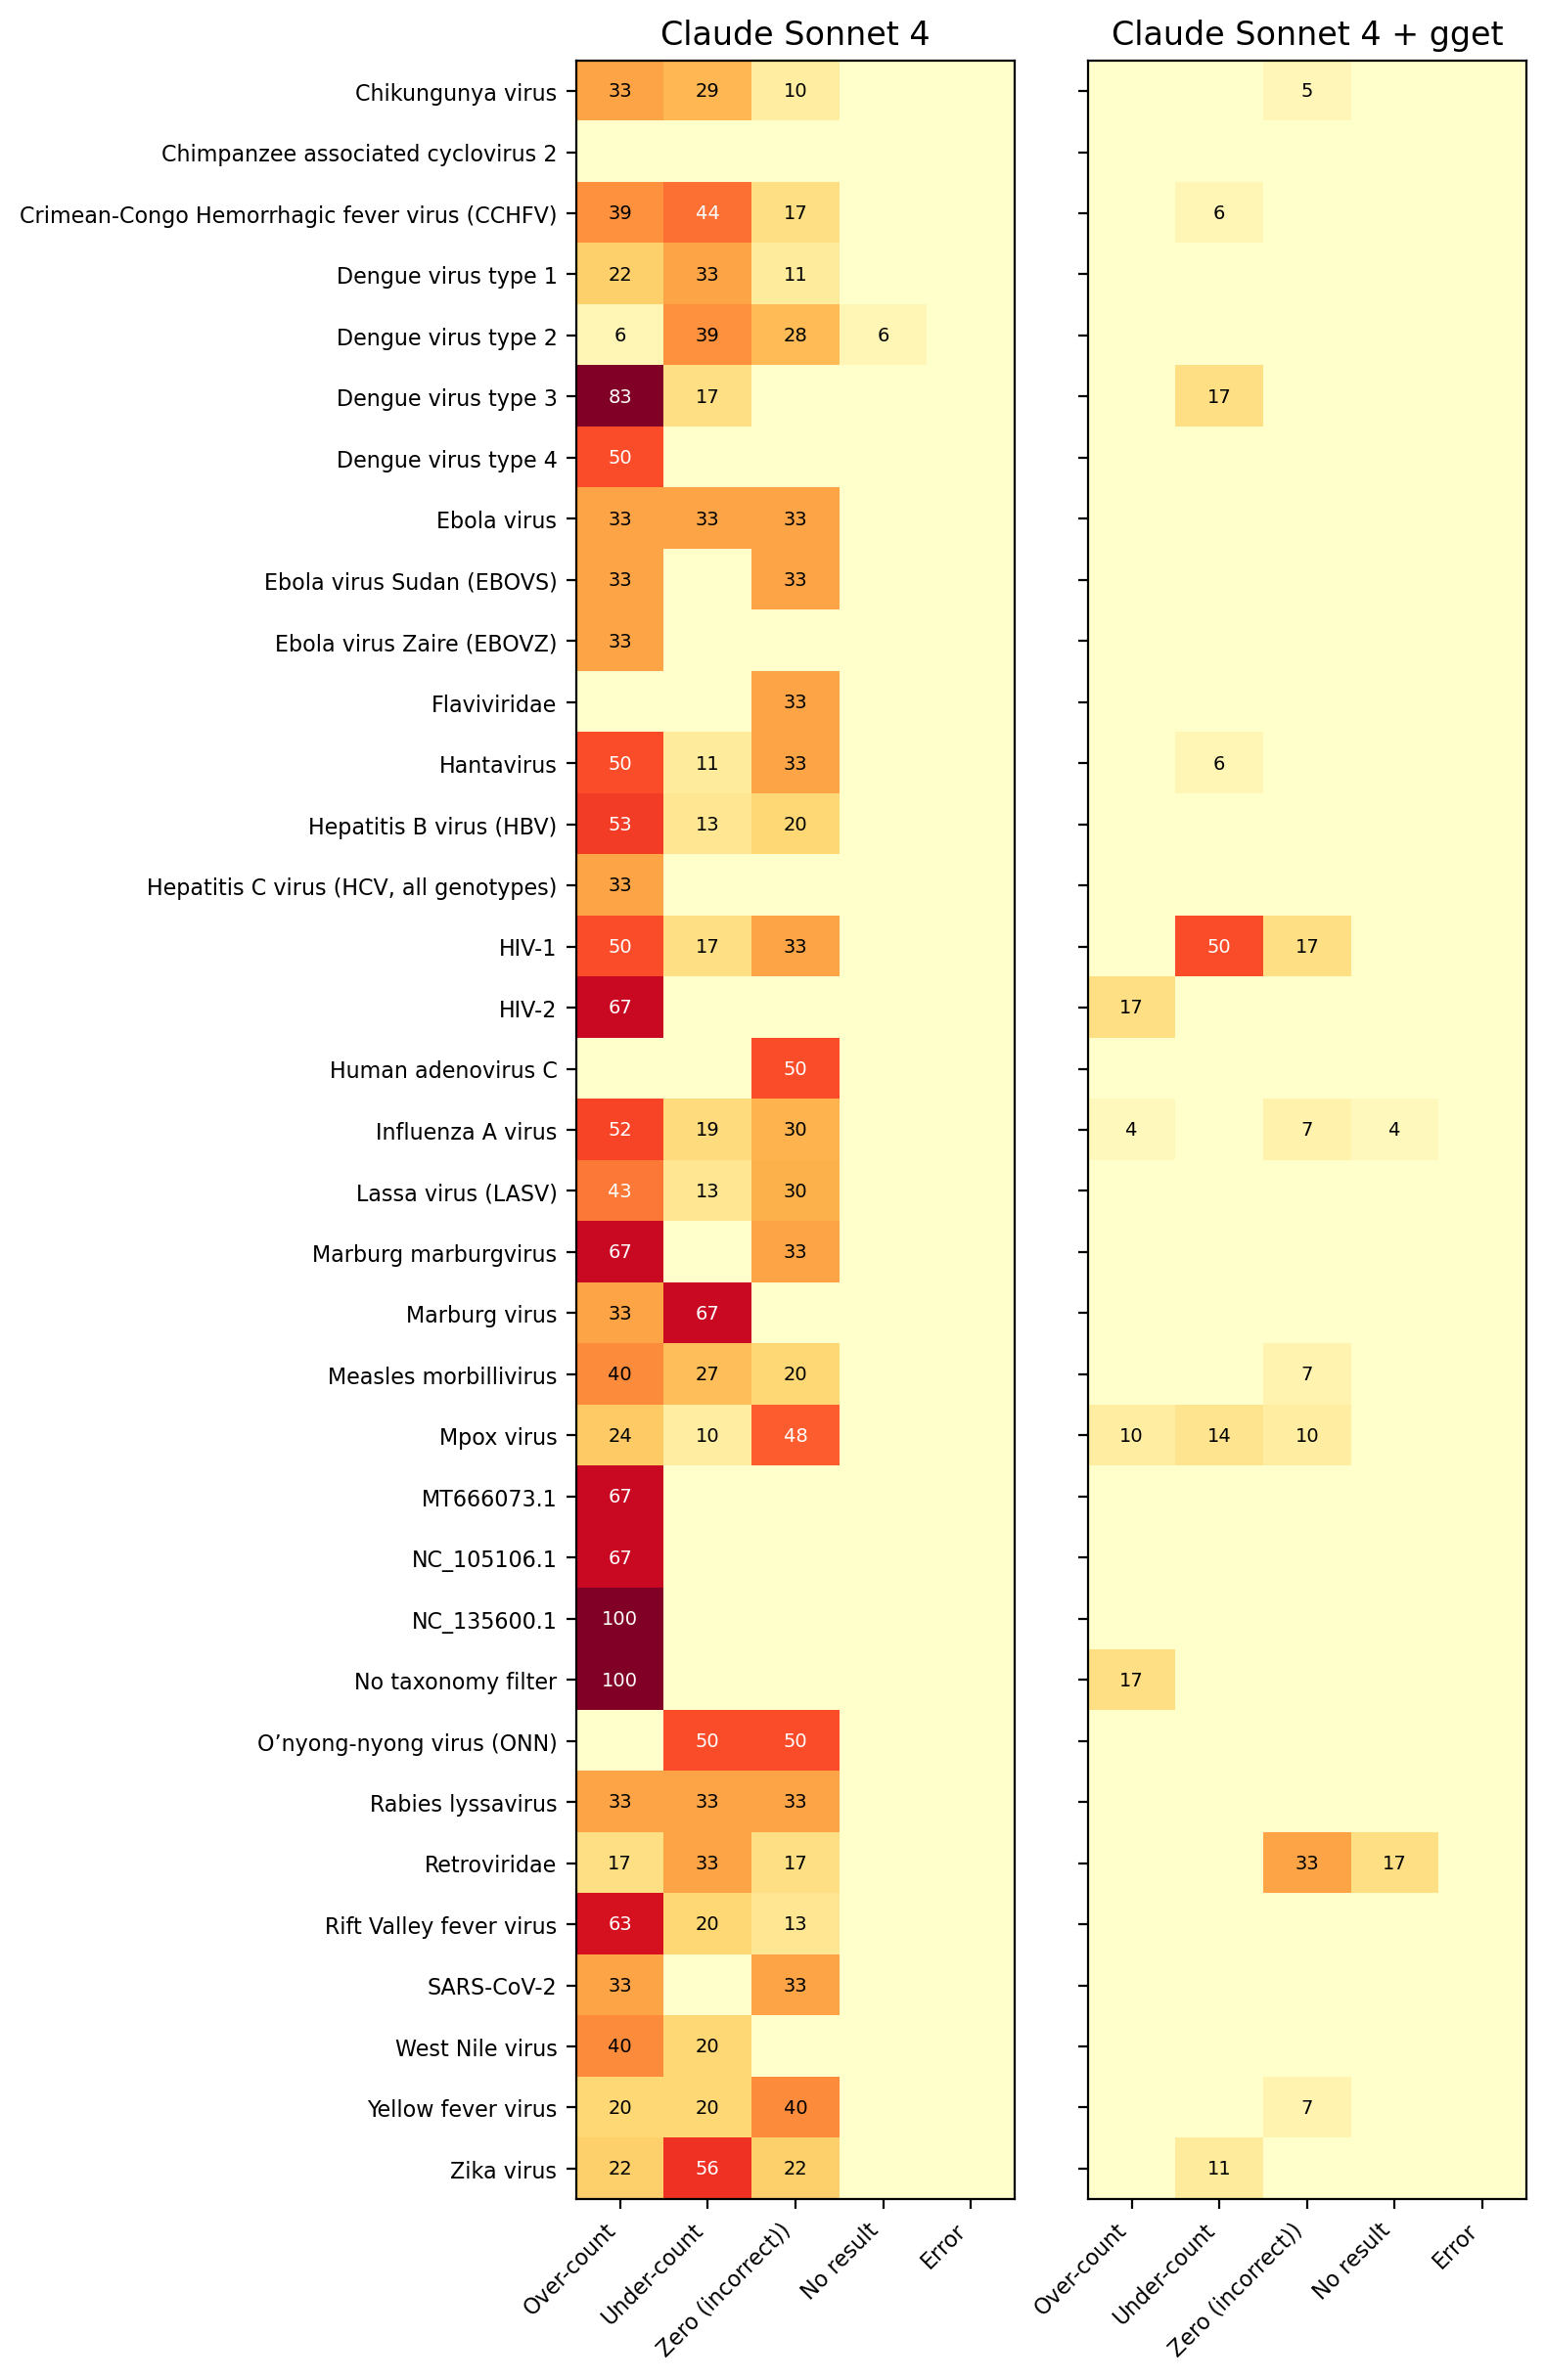

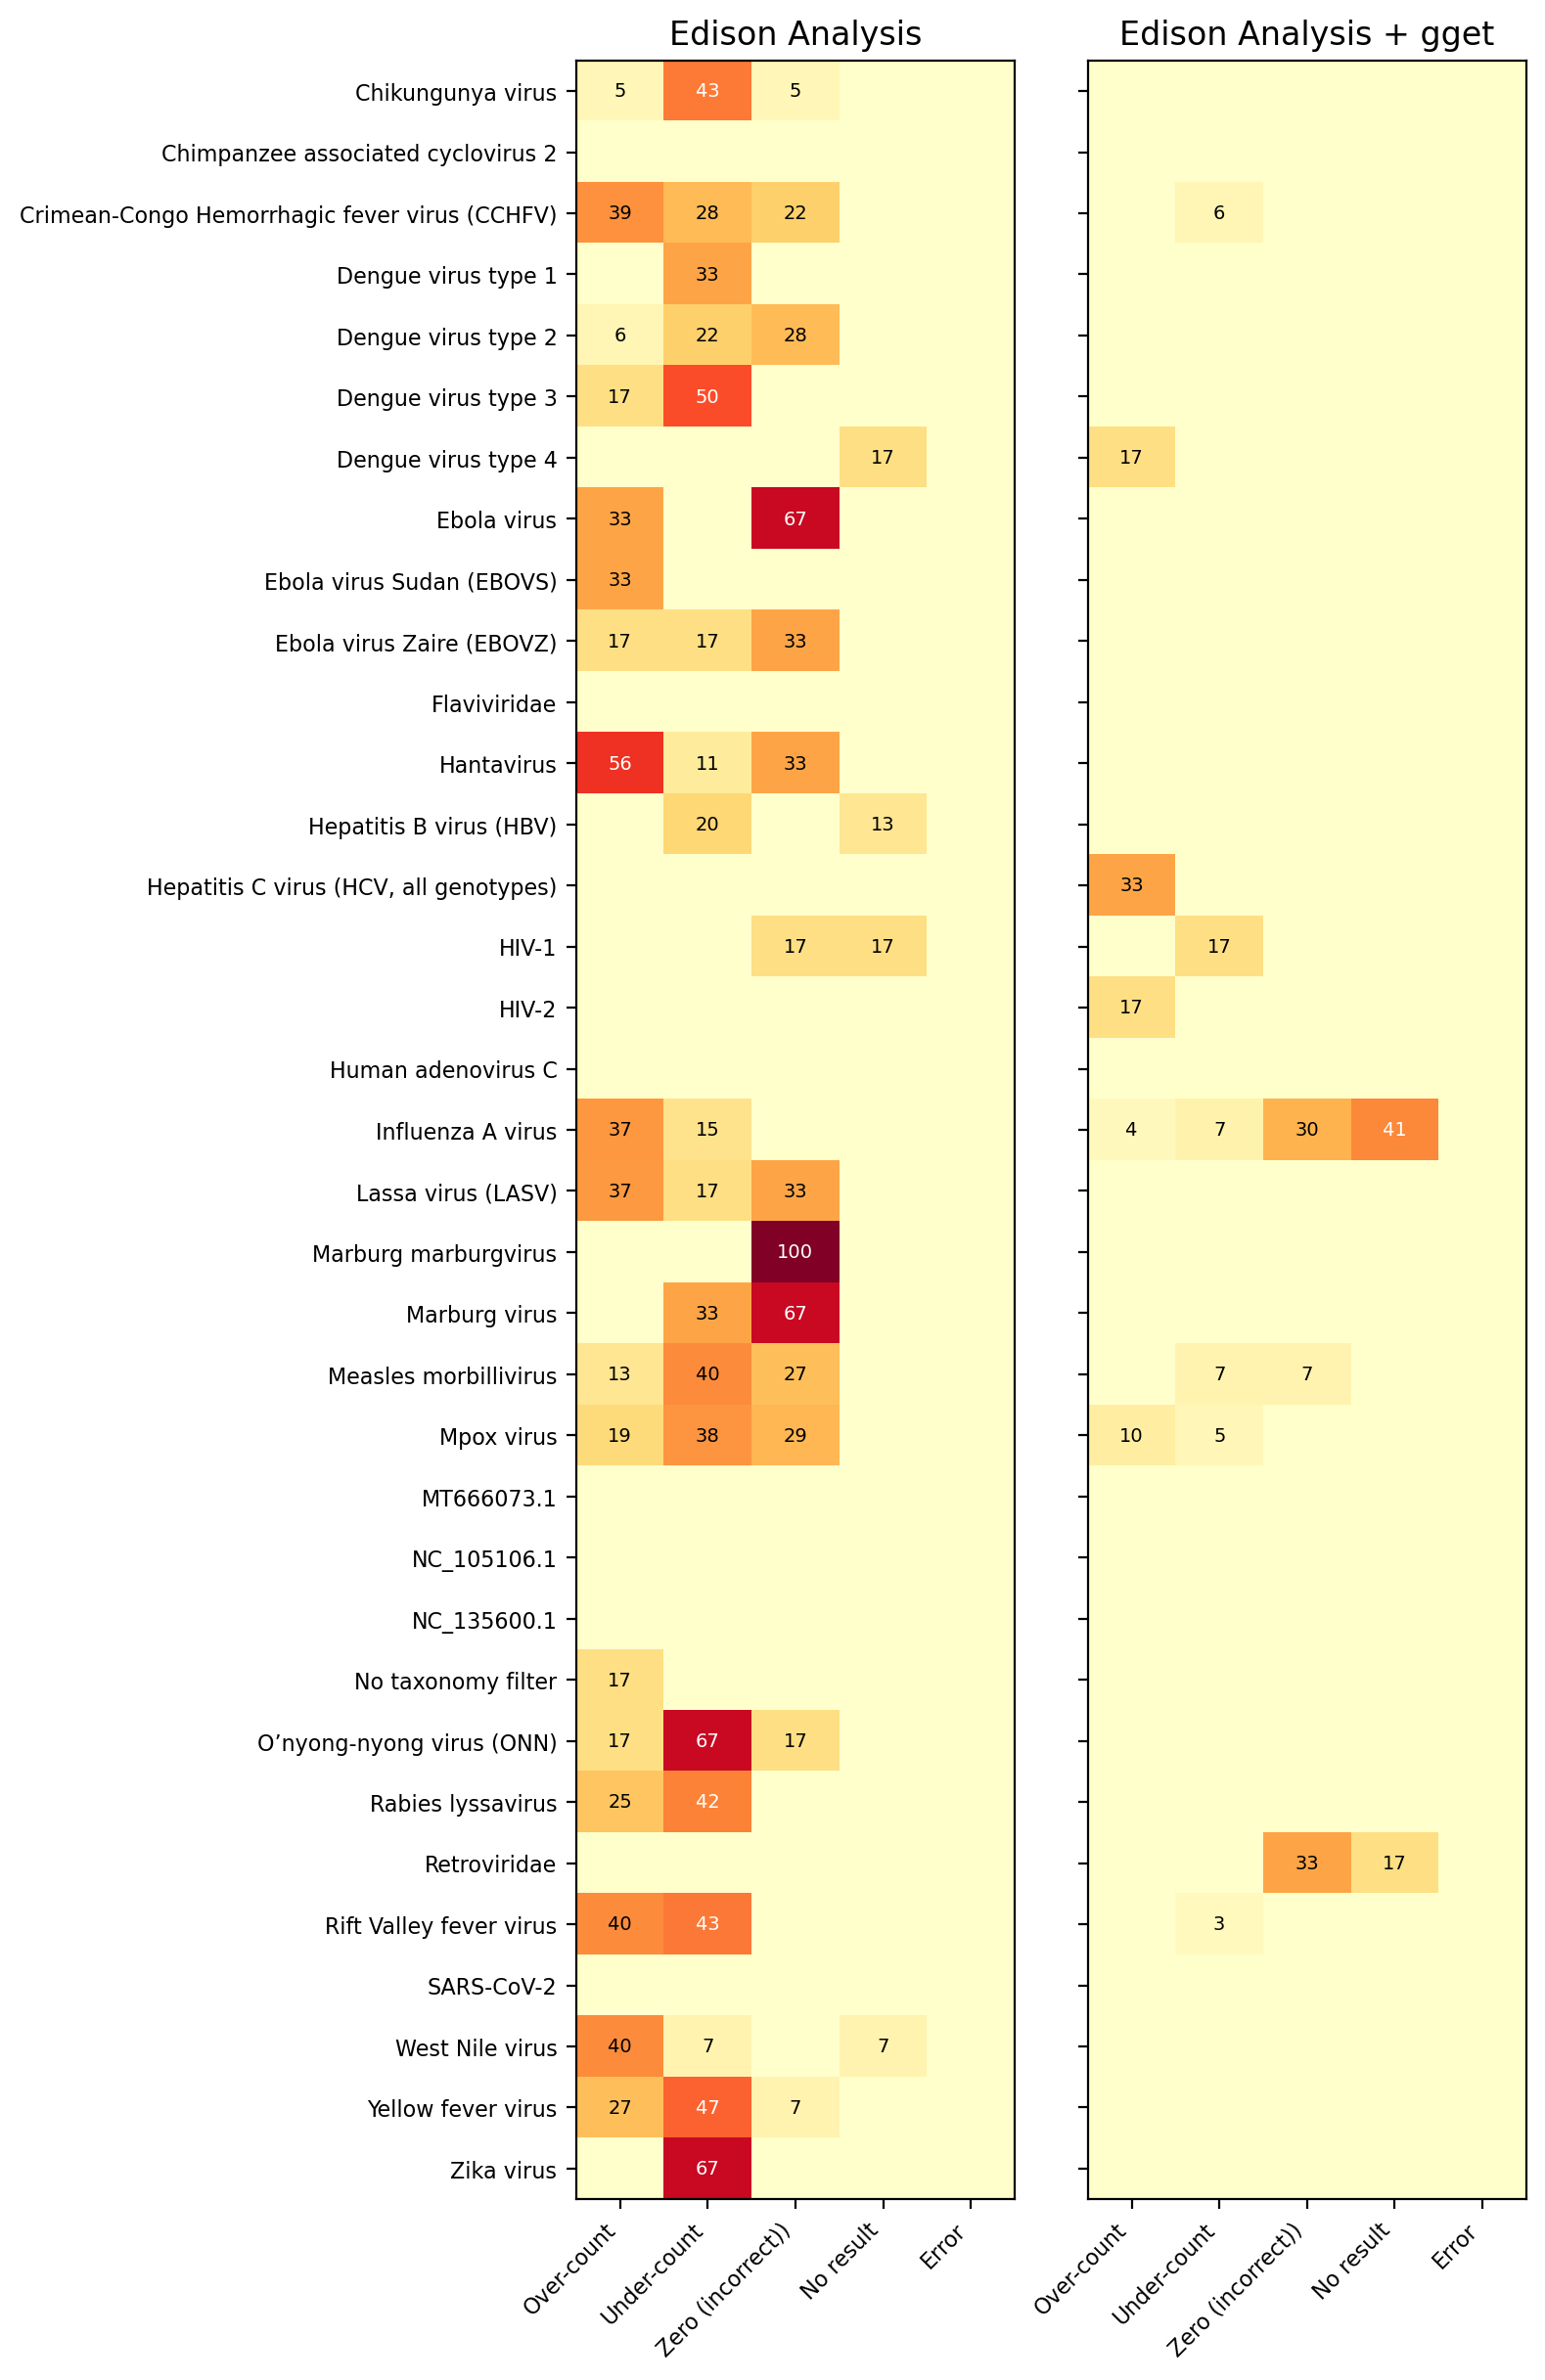

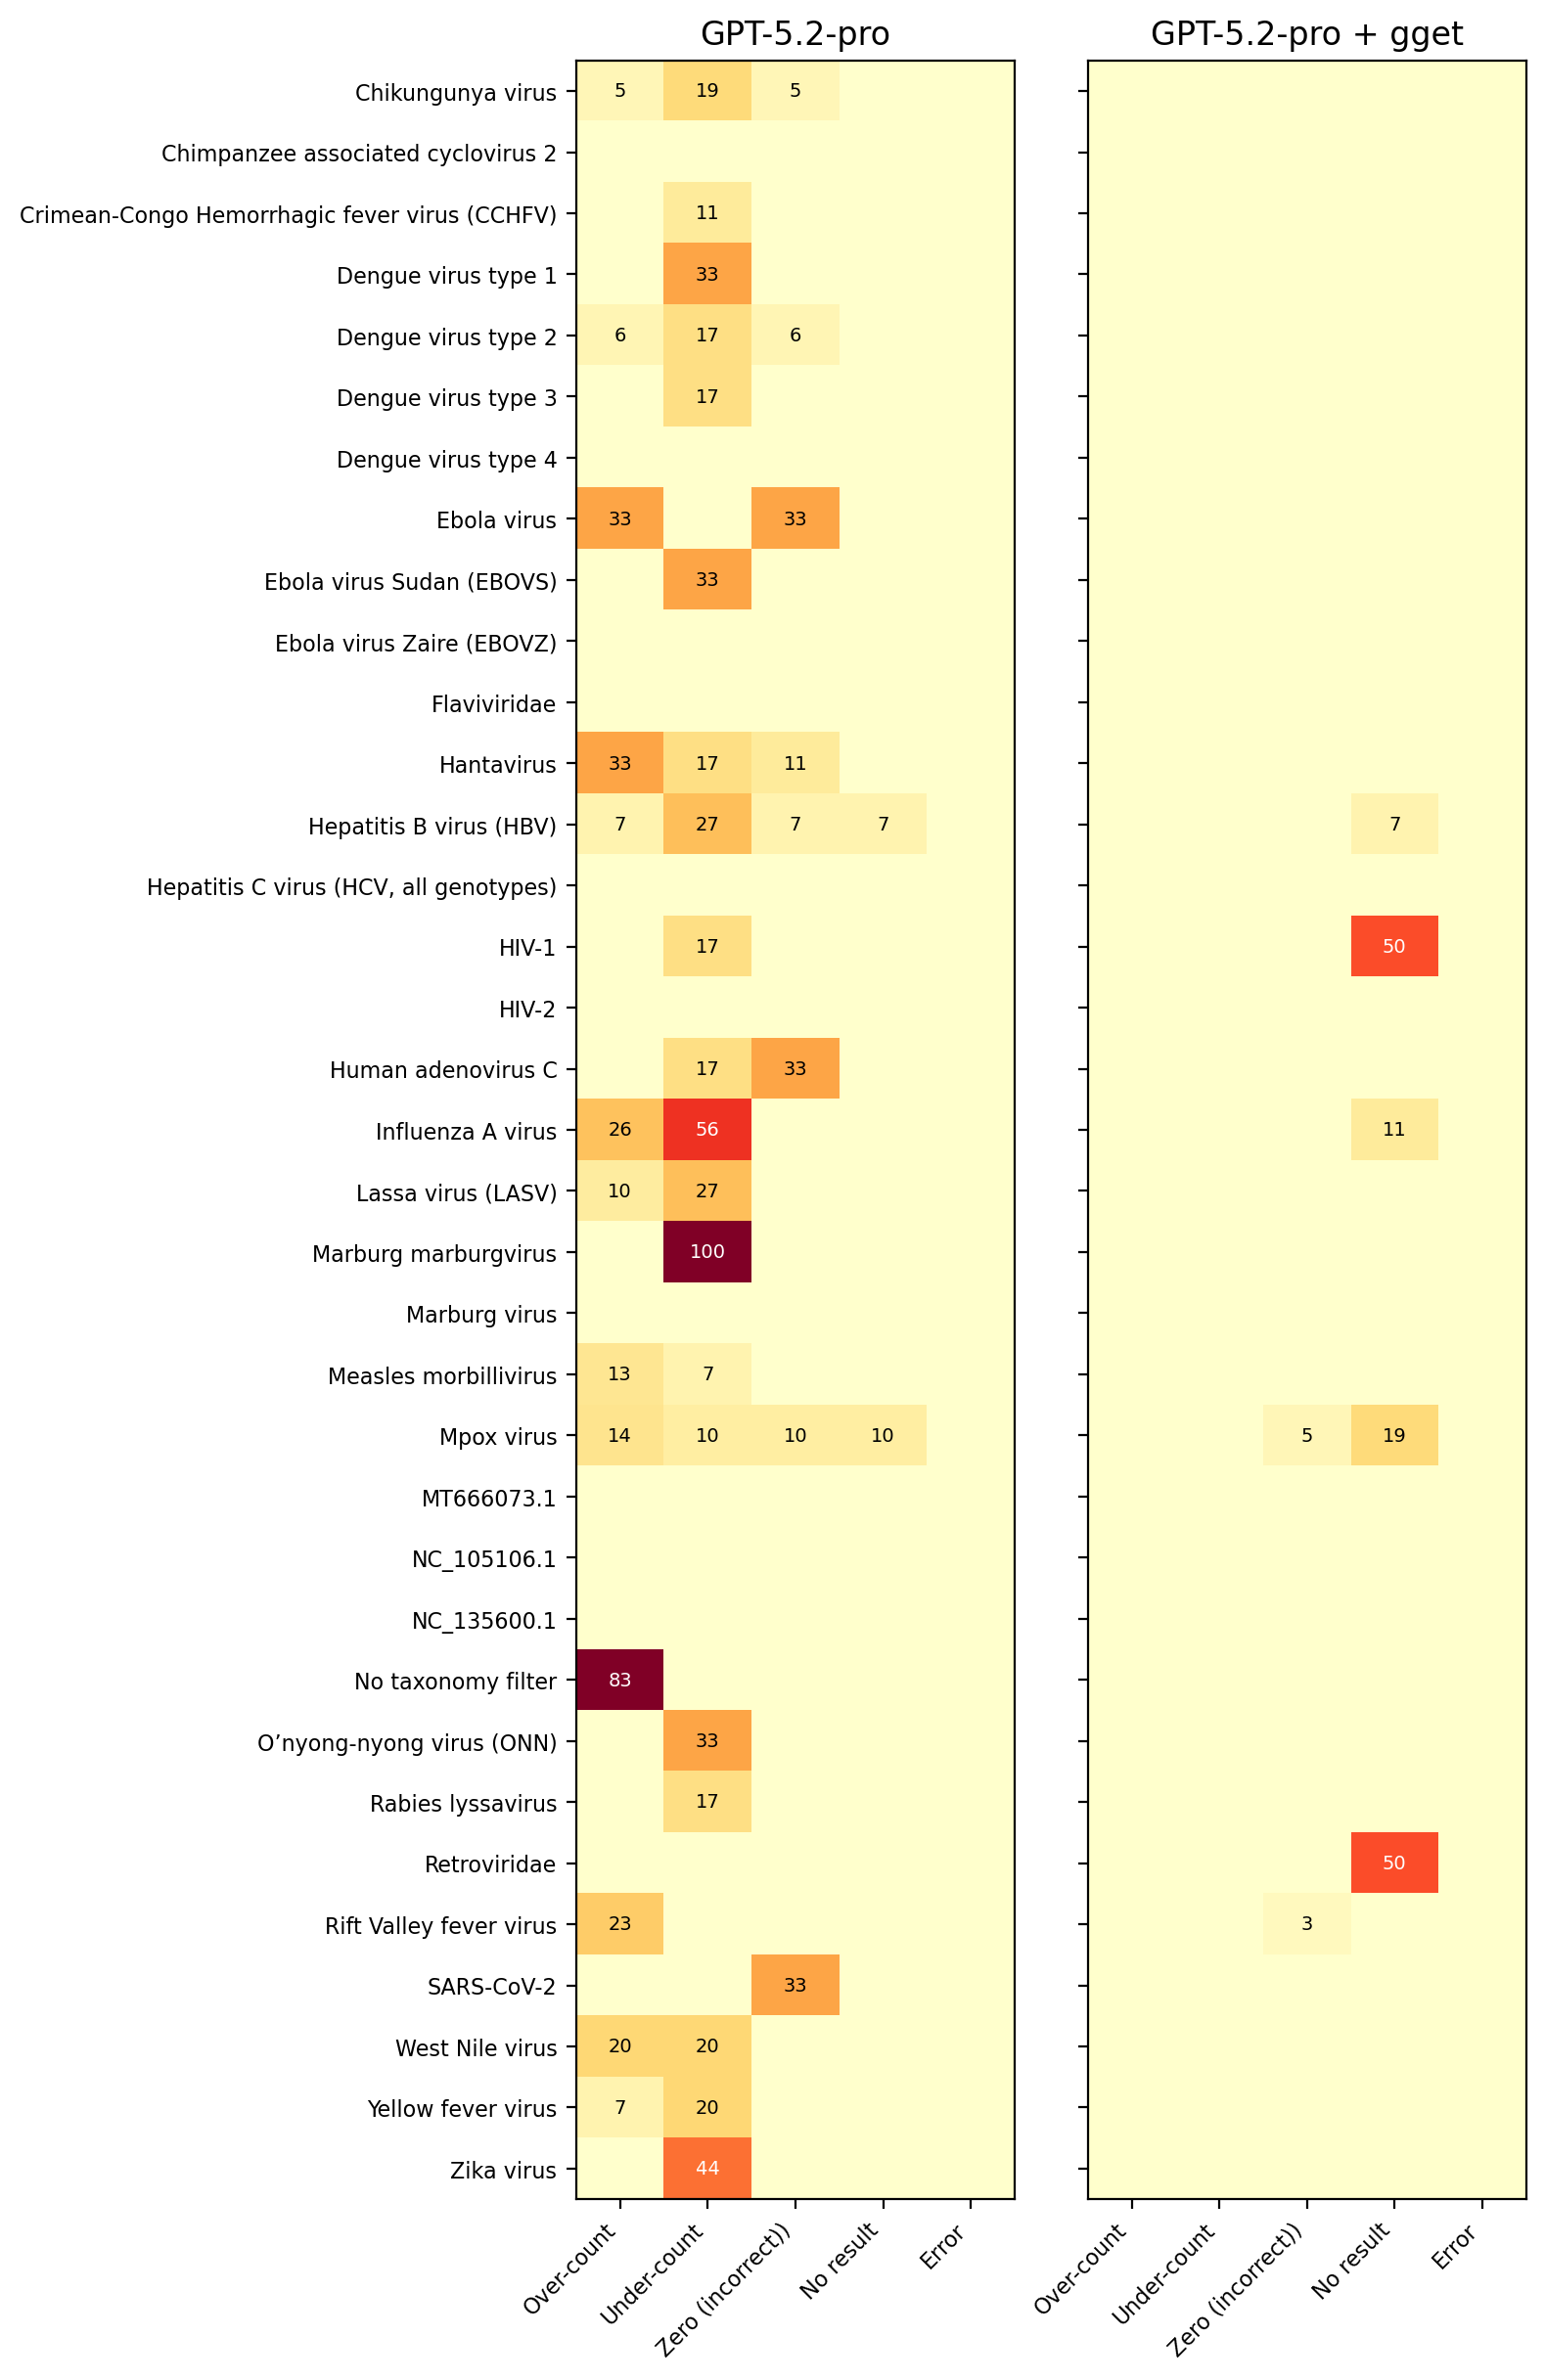

In [292]:
# For each LLM: heatmap of dominant failure mode per pathogen
for llm in sorted(results["llm"].unique()):
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(8, max(3, len(pathogens) * 0.35)),
                                   gridspec_kw={"width_ratios": [1, 1]}, sharey=True)

    for ax, variant, title in zip([ax0, ax1], ["no_gget", "with_gget"],
                                   [f"{llm}", f"{llm} + gget"]):
        sub = results[(results["llm"] == llm) & (results["variant"] == variant)]
        fail_outcomes = ["over_count", "under_count", "zero", "no_result", "error"]
        matrix = np.zeros((len(pathogens), len(fail_outcomes)))
        for i, p in enumerate(pathogens):
            p_sub = sub[sub["pathogen"] == p]
            total = len(p_sub)
            if total == 0:
                matrix[i, :] = np.nan
                continue
            for j, outcome in enumerate(fail_outcomes):
                matrix[i, j] = (p_sub["outcome"] == outcome).sum() / total * 100

        im = ax.imshow(matrix, aspect="auto", cmap="YlOrRd", vmin=0, vmax=80)
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                val = matrix[i, j]
                if np.isnan(val) or val == 0:
                    continue
                ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                        fontsize=FONTSIZE - 5, color="white" if val > 40 else "black")

        ax.set_xticks(range(len(fail_outcomes)))
        ax.set_xticklabels([outcome_labels[o] for o in fail_outcomes],
                           fontsize=FONTSIZE - 4, rotation=45, ha="right")
        ax.set_title(title, fontsize=FONTSIZE)

    ax0.set_yticks(range(len(pathogens)))
    ax0.set_yticklabels([p[0].upper() + p[1:] for p in pathogens], fontsize=FONTSIZE - 4)

    fig.tight_layout()
    plt.show()

## Raw response inspection for persistently wrong queries

Show the full raw responses for the hardest queries to understand failure root causes.

In [293]:
# For the top 5 universally-wrong queries, show raw responses from one LLM
inspect_qids = worst_qids[:5]
# Prefer Claude or GPT since they have reasoning
inspect_llm = "Claude Sonnet 4" if "Claude Sonnet 4" in reports["llm"].values else sorted(results["llm"].unique())[0]

for qid in inspect_qids:
    p = rename_pathogen(pathogen_map.get(qid, "?"))
    exp = configs[configs["query_id"] == qid]["expected_count"].iloc[0]
    print(f"\n{'='*80}")
    print(f"Query {qid}: {p} (expected={exp})")
    print(f"{'='*80}")

    for variant in ["no_gget", "with_gget"]:
        sub = merged[
            (merged["llm"] == inspect_llm) &
            (merged["variant"] == variant) &
            (merged["query_id"] == qid) &
            (merged["run_number"] == 1)  # just first run
        ]
        if sub.empty:
            continue
        row = sub.iloc[0]
        print(f"\n--- {inspect_llm} ({variant}), run 1 ---")
        print(f"Retrieved: {row['retrieved_count']}, Outcome: {row['outcome']}")
        raw = row.get("raw_response", "")
        if raw and isinstance(raw, str):
            # Truncate very long responses
            if len(raw) > 3000:
                print(raw[:1500])
                print(f"\n... [truncated, {len(raw)} chars total] ...\n")
                print(raw[-1500:])
            else:
                print(raw)


Query 19: HIV-2 (expected=0)

--- Claude Sonnet 4 (no_gget), run 1 ---
Retrieved: 41.0, Outcome: over_count
41

```json
{
  "methods": [
    "NCBI E-utilities API (ESearch, ESummary, EFetch)",
    "Manual filtering by geographic location keywords",
    "Sequence analysis for ambiguous character counting"
  ],
  "reasoning": [
    "Used NCBI E-utilities with TaxID 11709 for HIV-2, length filter ≥9000bp, and publication date 2020-2025",
    "Filtered by Africa geographic location using keyword matching in sequence titles (all from Senegal)",
    "Applied final filter for ≤10 ambiguous characters by analyzing FASTA sequences - all had 0 N's"
  ]
}
```

--- Claude Sonnet 4 (with_gget), run 1 ---
Retrieved: 0.0, Outcome: correct_zero
0

```json
{
  "methods": ["gget virus module via NCBI Virus API", "Applied sequential metadata and sequence-dependent filters"],
  "reasoning": [
    "Retrieved 7,663 total HIV-2 sequences from NCBI, filtered to 561 matching initial criteria", 
    "Applied g

## Deviation heatmap (all queries × all technologies)

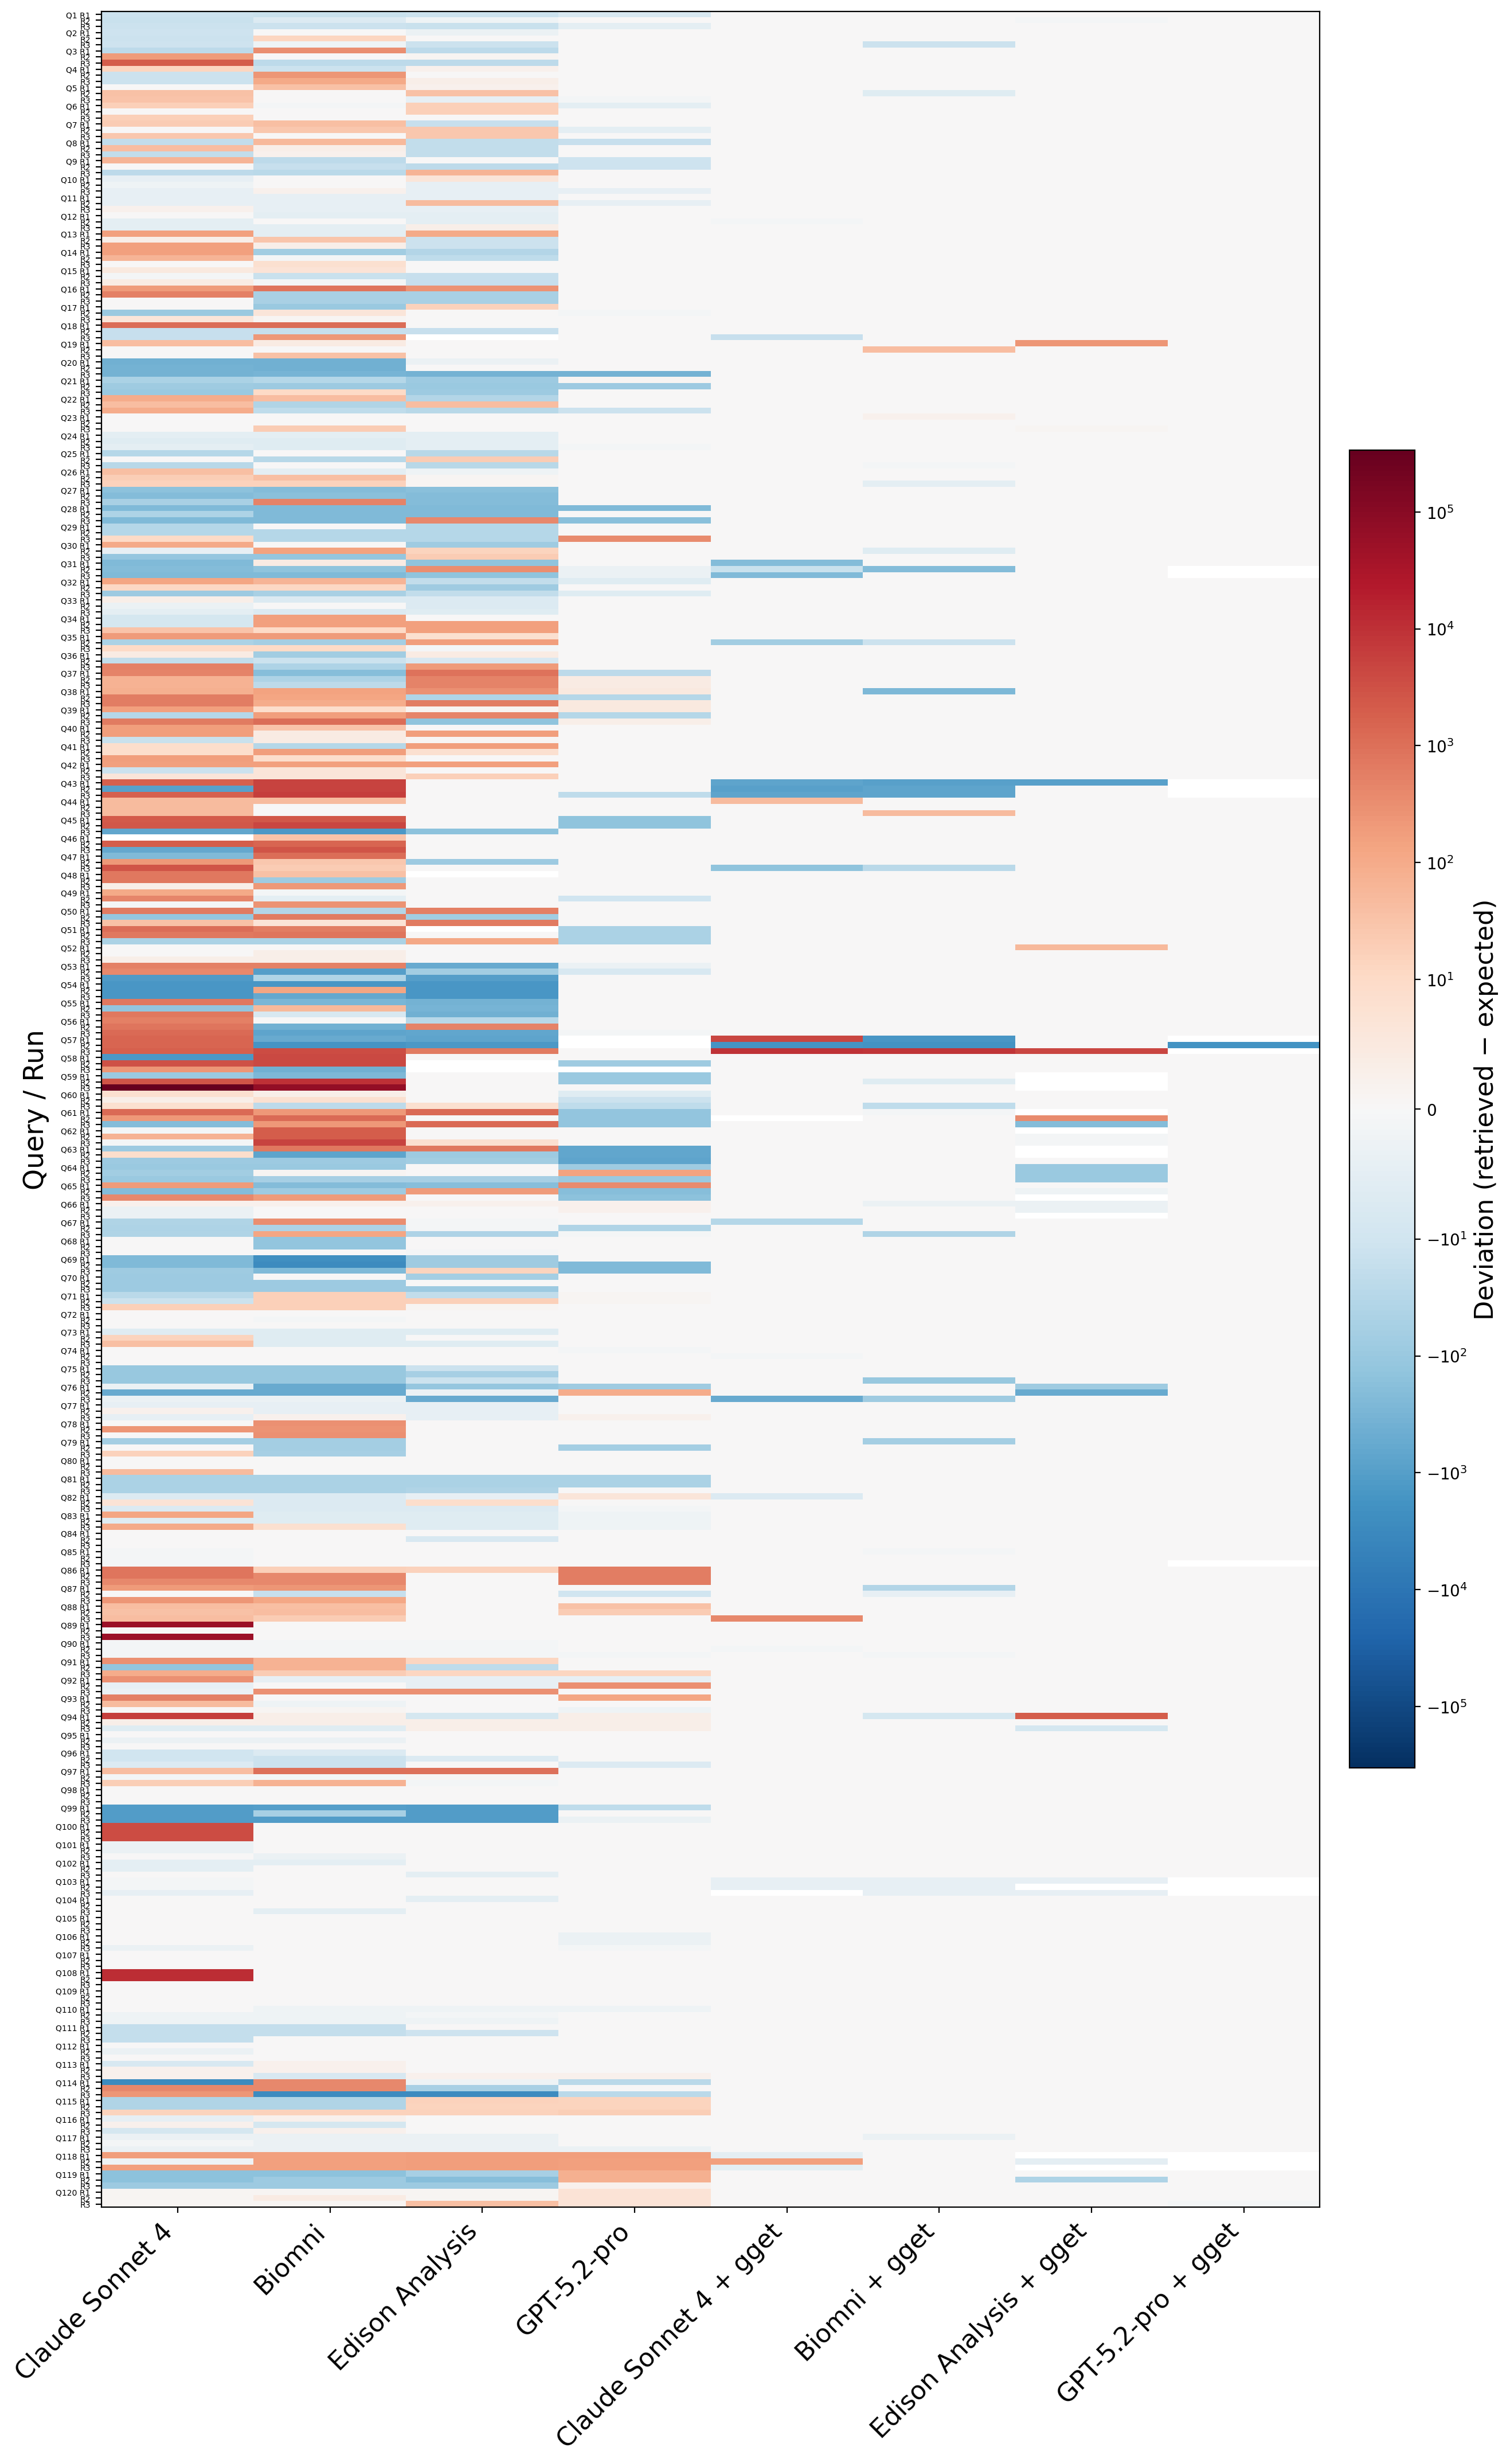

In [294]:
# Deviation heatmap: all queries/runs (y-axis) × all technologies (x-axis)
# Deviation = retrieved_count - expected_count; uses symmetric log color scale

from matplotlib.colors import SymLogNorm

# Build technology label column
results["tech"] = results["llm"] + results["variant"].map(
    {"no_gget": "", "with_gget": " + gget"}
)

# Define column order
tech_order = [
    "Claude Sonnet 4", "Biomni", "Edison Analysis", "GPT-5.2-pro",
    "Claude Sonnet 4 + gget", "Biomni + gget", "Edison Analysis + gget", "GPT-5.2-pro + gget",
]
tech_order = [t for t in tech_order if t in results["tech"].unique()]

# Build row labels: "Q{id} R{run}"
results["row_label"] = "Q" + results["query_id"].astype(str) + " R" + results["run_number"].astype(str)

# Sort rows by query_id then run_number
row_order = (
    results[["query_id", "run_number", "row_label"]]
    .drop_duplicates()
    .sort_values(["query_id", "run_number"])
    ["row_label"]
    .tolist()
)

# Pivot to matrix
heatmap_data = results.pivot_table(
    index="row_label", columns="tech", values="deviation", aggfunc="first"
)
heatmap_data = heatmap_data.reindex(index=row_order, columns=tech_order)

# Build display labels: Q{id} R1, R2, R3
display_labels = []
for i, label in enumerate(row_order):
    run = (i % 3) + 1
    if run == 1:
        display_labels.append(label)  # "Q{id} R1" — full label on first run
    else:
        display_labels.append(f"R{run}")

# Plot
n_rows = len(row_order)
fig_height = max(12, n_rows * 0.06)
fig, ax = plt.subplots(figsize=(14, fig_height))

vmax = np.nanmax(np.abs(heatmap_data.values))
norm = SymLogNorm(linthresh=10, vmin=-vmax, vmax=vmax)

im = ax.imshow(
    heatmap_data.values.astype(float),
    aspect="auto",
    cmap="RdBu_r",
    norm=norm,
    interpolation="nearest",
)

ax.set_xticks(range(len(tech_order)))
ax.set_xticklabels(tech_order, rotation=45, ha="right", fontsize=FONTSIZE + 4)

# Show all y-ticks with compact labels
ax.set_yticks(range(n_rows))
ax.set_yticklabels(display_labels, fontsize=5)

ax.set_ylabel("Query / Run", fontsize=FONTSIZE + 5)
# ax.set_xlabel("Technology", fontsize=FONTSIZE + 5)
# ax.set_title("Deviation (retrieved − expected) per query-run", fontsize=FONTSIZE + 7)

cbar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Deviation (retrieved − expected)", fontsize=FONTSIZE + 4)

fig.tight_layout()

fig.savefig("../figures/all_queries_deviation_heatmap.png", bbox_inches="tight", dpi=300)
plt.show()